# Практическая работа № 4

In [83]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, MinMaxScaler
from sklearnex import patch_sklearn
patch_sklearn()
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error, mean_absolute_error, \
    mean_absolute_percentage_error
from sklearn.linear_model import Lasso, Ridge, ElasticNet, SGDRegressor
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split
import optuna
import seaborn as sns

Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


Для начала загрузим таблицу с информацией о результатах построения моделей в практической работе № 3.

In [34]:
practice3_results = pd.read_csv("datasets/practice3_results.csv", index_col=0)

practice3_results

,Train Data,Train Data.1,Train Data.2,Train Data.3,Train Data.4,Test Data,Test Data.1,Test Data.2,Test Data.3,Test Data.4
NaN,R2,MSE,RMSE,MAE,MAPE,R2,MSE,RMSE,MAE,MAPE
Linear regression without regularization,0.82,0.184,0.4289,0.3427,1.7935,0.81,0.1876,0.4331,0.3452,3.3207
Linear regression with Lasso regularization,0.82,0.1841,0.4291,0.3432,1.7848,0.81,0.1874,0.4329,0.3455,3.3022
Linear regression with Ridge regularization,0.82,0.1843,0.4293,0.3427,1.7413,0.81,0.1873,0.4327,0.3441,3.2156
Linear regression with Elastic Net (get with GridSearch),0.82,0.1841,0.429,0.343,1.7771,0.81,0.1873,0.4328,0.3451,3.2871
Linear regression with Elastic Net (get with RandomSearch),0.82,0.1841,0.429,0.3427,1.7629,0.81,0.1873,0.4328,0.3445,3.2592
Linear regression with Elastic Net (get with Optuna),0.82,0.1843,0.4293,0.3429,1.7385,0.81,0.1872,0.4327,0.3442,3.2094
Polynomial regression (deg 2) without regularization,0.93,0.0725,0.2692,0.2042,0.9169,0.92,0.0786,0.2803,0.2118,1.71
Polynomial regression (deg 3) without regularization,0.97,0.0335,0.1832,0.1282,0.5769,0.96,0.0397,0.1991,0.1381,0.6519
Polynomial regression (deg 4) without regularization,0.98,0.018,0.1343,0.0921,0.3423,0.97,0.0345,0.1856,0.1252,0.8196


Удалим первую строку из датафрайма и сделаем корректные имена столбцов

In [35]:
practice3_results.drop(practice3_results.index[0], axis=0, inplace=True)

metrics = ["R2", "MSE", "RMSE", "MAE", "MAPE"]

columns = pd.MultiIndex.from_product([["Train Data", "Test Data"], metrics])
practice3_results.columns = columns
practice3_results

Train Data                  \
                                                           R2     MSE    RMSE   
Linear regression without regularization                 0.82   0.184  0.4289   
Linear regression with Lasso regularization              0.82  0.1841  0.4291   
Linear regression with Ridge regularization              0.82  0.1843  0.4293   
Linear regression with Elastic Net (get with Gr...       0.82  0.1841   0.429   
Linear regression with Elastic Net (get with Ra...       0.82  0.1841   0.429   
Linear regression with Elastic Net (get with Op...       0.82  0.1843  0.4293   
Polynomial regression (deg 2) without regulariz...       0.93  0.0725  0.2692   
Polynomial regression (deg 3) without regulariz...       0.97  0.0335  0.1832   
Polynomial regression (deg 4) without regulariz...       0.98   0.018  0.1343   
Polynomial regression(deg 2) with L1 (get with ...       0.93  0.0727  0.2697   
Polynomial regression(deg 2) with L1 (get with ...       0.91  0.0921  0.3035   
Polynomial regression(deg 2) with L1 (get with ...       0.93  0.0727  0.2697   
Polynomial regression (deg 2) with L2 (get with...       0.93  0.0725  0.2692   
Polynomial regression (deg 2) with L2 (get with...       0.93  0.0725  0.2692   
Polynomial regression (deg 2) with L2 (get with...       0.93  0.0725  0.2692   
Polynomial regression (deg 2) with Elastic Net ...       0.93  0.0726  0.2695   
Polynomial regression (deg 2) with Elastic Net ...       0.93  0.0726  0.2695   
Polynomial regression (deg 2) with Elastic Net ...       0.93  0.0725  0.2692   
Polynomial regression (deg 3) with L1 (GridSearch)       0.97  0.0349  0.1869   
Polynomial regression (deg 3) with L1 (RandomSe...       0.92  0.0814  0.2853   
Polynomial regression (deg 3) with L1 (Optuna)           0.97  0.0349  0.1869   
Polynomial regression (deg 3) with L2 (GridSearch)       0.97  0.0336  0.1832   
Polynomial regression (deg 3) with L2 (RandomSe...       0.97  0.0335  0.1832   
Polynomial regression (deg 3) with L2 (Optuna)           0.97  0.0335  0.1832   
Polynomial regression (deg 3) with Elastic Net ...       0.97  0.0344  0.1854   
Polynomial regression (deg 3) with Elastic Net ...       0.97  0.0345  0.1858   
Polynomial regression (deg 3) with Elastic Net ...       0.97  0.0339  0.1841   
Polynomial regression (deg 4) with L1 (GridSearch)       0.98  0.0231  0.1519   
Polynomial regression (deg 4) with L1 (RandomSe...       0.91    0.09     0.3   
Polynomial regression (deg 4) with L1 (Optuna)           0.98  0.0231  0.1519   
Polynomial regression (deg 4) with L2 (GridSearch)       0.98  0.0181  0.1346   
Polynomial regression (deg 4) with L2 (RandomSe...       0.98  0.0182   0.135   
Polynomial regression (deg 4) with L2 (Optuna)           0.98   0.018  0.1343   
Polynomial regression (deg 4) with Elastic Net ...       0.98  0.0225  0.1501   
Polynomial regression (deg 4) with Elastic Net ...       0.98  0.0209  0.1445   
Polynomial regression (deg 4) with Elastic Net ...       0.98  0.0208  0.1442   

                                                                   Test Data  \
                                                       MAE    MAPE        R2   
Linear regression without regularization            0.3427  1.7935      0.81   
Linear regression with Lasso regularization         0.3432  1.7848      0.81   
Linear regression with Ridge regularization         0.3427  1.7413      0.81   
Linear regression with Elastic Net (get with Gr...   0.343  1.7771      0.81   
Linear regression with Elastic Net (get with Ra...  0.3427  1.7629      0.81   
Linear regression with Elastic Net (get with Op...  0.3429  1.7385      0.81   
Polynomial regression (deg 2) without regulariz...  0.2042  0.9169      0.92   
Polynomial regression (deg 3) without regulariz...  0.1282  0.5769      0.96   
Polynomial regression (deg 4) without regulariz...  0.0921  0.3423      0.97   
Polynomial regression(deg 2) with L1 (get with ...  0.2046  0.9051      0.92   
Polynomial r

Создадим две таблицы для работы: первая - с тренировочными и валидационными выборками, а вторая - с тестовыми данными. В итоге работы объединим их в финальную результирующую таблицу

In [36]:
train_and_val_metrics_comparing_columns = pd.MultiIndex.from_product([["Train Data", "Val Data"], metrics]).to_frame()
train_and_val_metrics_comparing = pd.DataFrame(columns=train_and_val_metrics_comparing_columns)
train_and_val_metrics_comparing

,"(Train Data, R2)","(Train Data, MSE)","(Train Data, RMSE)","(Train Data, MAE)","(Train Data, MAPE)","(Val Data, R2)","(Val Data, MSE)","(Val Data, RMSE)","(Val Data, MAE)","(Val Data, MAPE)"


In [37]:
test_metrics_columns = pd.MultiIndex.from_product([["Test Data"], metrics])
test_metrics_info = pd.DataFrame(columns=test_metrics_columns)
test_metrics_info

Empty DataFrame
Columns: [(Test Data, R2), (Test Data, MSE), (Test Data, RMSE), (Test Data, MAE), (Test Data, MAPE)]
Index: []

Для избежания дублирования кода используем некоторые кастомные функции

Функция для получения метрик `get_metrics`

In [38]:
def get_metrics(y_test, y_predicted, print_results=False):
    names_of_metrics = ["R2", "MSE", "RMSE", "MAE", "MAPE"]
    results = [
        round(r2_score(y_test, y_predicted), 2),
        round(mean_squared_error(y_test, y_predicted), 4),
        round(root_mean_squared_error(y_test, y_predicted), 4),
        round(mean_absolute_error(y_test, y_predicted), 4),
        round(mean_absolute_percentage_error(y_test, y_predicted), 4)
    ]

    if print_results:
        for name, result in zip(names_of_metrics, results):
            print(f"{name}: {result}")

    return results

Функция для вставки метрик в таблицу с тренировочными и валидационными данными `input_metrics_into_the_train_val_table`

In [39]:
def input_metrics_into_the_train_val_table(name_of_model,
                          predict_on_train_y, y_train,
                          predict_on_val_y, y_val):
    val_metrics = get_metrics(y_val, predict_on_val_y)

    train_metrics = get_metrics(y_train, predict_on_train_y)

    train_and_val_metrics_comparing.loc[name_of_model] = train_metrics  + val_metrics

Функция для вставки метрик в таблицу с тестовыми данными `input_metrics_into_the_train_val_table`

In [40]:
def input_metrics_into_the_test_table(name_of_model,
                          predict_on_test_y, y_test):
    test_metrics = get_metrics(y_test, predict_on_test_y)

    test_metrics_info.loc[name_of_model] = test_metrics

Функция `train_models_with_reg ` используется для получения моделей с L1, L2 и ElasticNet регуляризациями с помощью GridSearch, RandomizedSearchCV и фреймворка Optuna.

In [41]:
optuna.logging.set_verbosity(optuna.logging.WARNING)
def train_models_with_reg(X_train, y_train, X_val, y_val, reg_config):

    result={}


    for name, reg_info in reg_config.items():

        param_grid = reg_info["param_grid"]
        type_of_reg = reg_info["reg"]

        grid_search_model = GridSearchCV(
            param_grid=param_grid,
            estimator=type_of_reg(max_iter=1000),
            scoring="neg_mean_squared_error",
            cv=3
        )

        grid_search_model.fit(X_train, y_train)

        random_search_model = RandomizedSearchCV(
            param_distributions=param_grid,
            estimator=type_of_reg(max_iter=1000),
            scoring="neg_mean_squared_error",
            random_state=42,
            cv=3
        )

        random_search_model.fit(X_train, y_train)

        def objective(trial):
            trial_params = {}
            for p_name, p_values in param_grid.items():
                if isinstance(p_values[0], float):
                    trial_params[p_name] = trial.suggest_float(p_name, min(p_values), max(p_values), log=True)
                else:
                    trial_params[p_name] = trial.suggest_categorical(p_name, p_values)

            model = type_of_reg(**trial_params)
            model.fit(X_train, y_train)
            score = mean_squared_error(y_val, model.predict(X_val))
            return score

        study = optuna.create_study(direction='minimize')
        study.optimize(objective, n_trials=100, show_progress_bar=False)

        optuna_model = type_of_reg(**study.best_params)
        optuna_model.fit(X_train, y_train)

        result[name] = {}
        result[name]["GridSearch"] = {
            "model": grid_search_model.best_estimator_,
            "best_params": grid_search_model.best_params_
        }
        result[name]["RandomSearch"] = {
            "model": random_search_model.best_estimator_,
            "best_params": random_search_model.best_params_
        }
        result[name]["Optuna"] = {
            "model": optuna_model,
            "best_params": study.best_params
        }

    return result

## Сохранение данных в программные переменные

### Разделение данных на тренировочную, валидационную и тестовую выборки

Разделим данные в пропорциях 80 - 10 - 10

In [42]:
data = pd.read_csv("datasets/practice3_preprocessing_ds.csv", index_col=0)

X = data.drop("stab", axis=1)
y = data["stab"]

X_train, X_val_test, y_train, y_val_test = train_test_split(X, y, test_size=0.2)
X_val, X_test, y_val, y_test = train_test_split(X_val_test, y_val_test, test_size=0.5)

print(f"Количество объектов в общей выборке: {len(X)}\n"
      f"Количество объектов в тренировочной выборке: {len(X_train)}\n"
      f"Количество объектов в валидационной выборке: {len(X_val)}\n"
      f"Количество объектов в тестовой выборке: {len(X_test)}")

Количество объектов в общей выборке: 10000
Количество объектов в тренировочной выборке: 8000
Количество объектов в валидационной выборке: 1000
Количество объектов в тестовой выборке: 1000


### Модель множественной регрессии без регуляризации

In [43]:
pipelines = []
multiple_regression_pipeline =
multiple_regression = LinearRegression()
multiple_regression.fit(X_train, y_train)

train_predict = multiple_regression.predict(X_train)
val_predict = multiple_regression.predict(X_val)
test_predict = multiple_regression.predict(X_test)

input_metrics_into_the_train_val_table("Multiple regression",
                          train_predict, y_train,
                          val_predict, y_val)

input_metrics_into_the_test_table(f"Multiple regression", test_predict, y_test)

train_and_val_metrics_comparing.loc["Multiple regression"]

(Train Data, R2)      0.8200
(Train Data, MSE)     0.1836
(Train Data, RMSE)    0.4284
(Train Data, MAE)     0.3416
(Train Data, MAPE)    2.1711
(Val Data, R2)        0.8100
(Val Data, MSE)       0.1863
(Val Data, RMSE)      0.4317
(Val Data, MAE)       0.3501
(Val Data, MAPE)      1.6128
Name: Multiple regression, dtype: float64

Text(0.5, 1.0, 'Множественная регрессия без регуляризации')

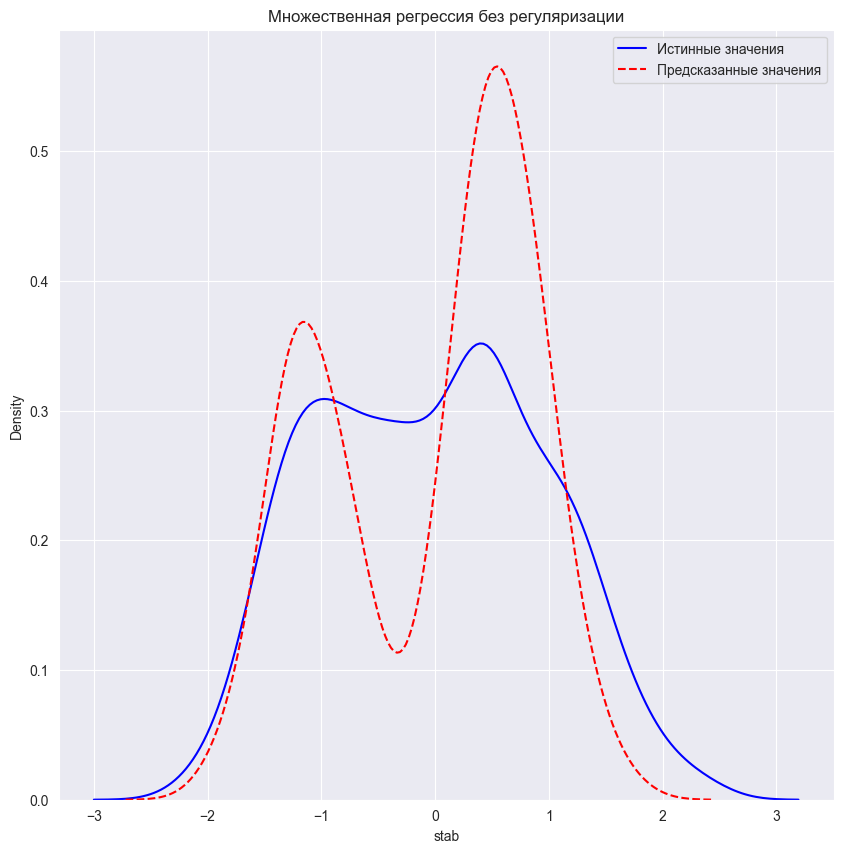

In [44]:
plt.figure(figsize=(10, 10))

sns.kdeplot(y_val, color="blue", label="Истинные значения")

sns.kdeplot(val_predict, linestyle="--", color="red", label="Предсказанные значения")

plt.grid(True)
plt.legend()
plt.title("Множественная регрессия без регуляризации")

Значения метрик неплохие. На валидационной выборке модель показала себя лучше, чем на тестовой выборке. Попробуем применить регуляризацию к модели

### Множественная регрессия с регуляризацией

In [45]:
alpha_range = np.logspace(-3, 2).tolist()
reg_config = {
    "L1": {
        "reg": Lasso,
        "param_grid": {"alpha": alpha_range}
    },
    "L2":
        {
            "reg": Ridge,
            "param_grid": {"alpha": alpha_range}
        },
    "EN":
        {
            "reg": ElasticNet,
            "param_grid":{
                    "alpha": alpha_range,
                    "l1_ratio": np.arange(0.1, 1, 0.3).tolist()
            }

        }

}

In [46]:
multiple_model_reg = train_models_with_reg(X_train, y_train, X_val, y_val, reg_config)
multiple_model_reg

{'L1': {'GridSearch': {'model': Lasso(alpha=0.0020235896477251575),
   'best_params': {'alpha': 0.0020235896477251575}},
  'RandomSearch': {'model': Lasso(alpha=0.021209508879201904),
   'best_params': {'alpha': 0.021209508879201904}},
  'Optuna': {'model': Lasso(alpha=0.00649483790006898),
   'best_params': {'alpha': 0.00649483790006898}}},
 'L2': {'GridSearch': {'model': Ridge(alpha=1.151395399326448, max_iter=1000),
   'best_params': {'alpha': 1.151395399326448}},
  'RandomSearch': {'model': Ridge(alpha=1.151395399326448, max_iter=1000),
   'best_params': {'alpha': 1.151395399326448}},
  'Optuna': {'model': Ridge(alpha=4.472390122293402),
   'best_params': {'alpha': 4.472390122293402}}},
 'EN': {'GridSearch': {'model': ElasticNet(alpha=0.002559547922699536, l1_ratio=0.7000000000000001),
   'best_params': {'alpha': 0.002559547922699536,
    'l1_ratio': 0.7000000000000001}},
  'RandomSearch': {'model': ElasticNet(alpha=0.004094915062380427, l1_ratio=0.1),
   'best_params': {'l1_ratio'

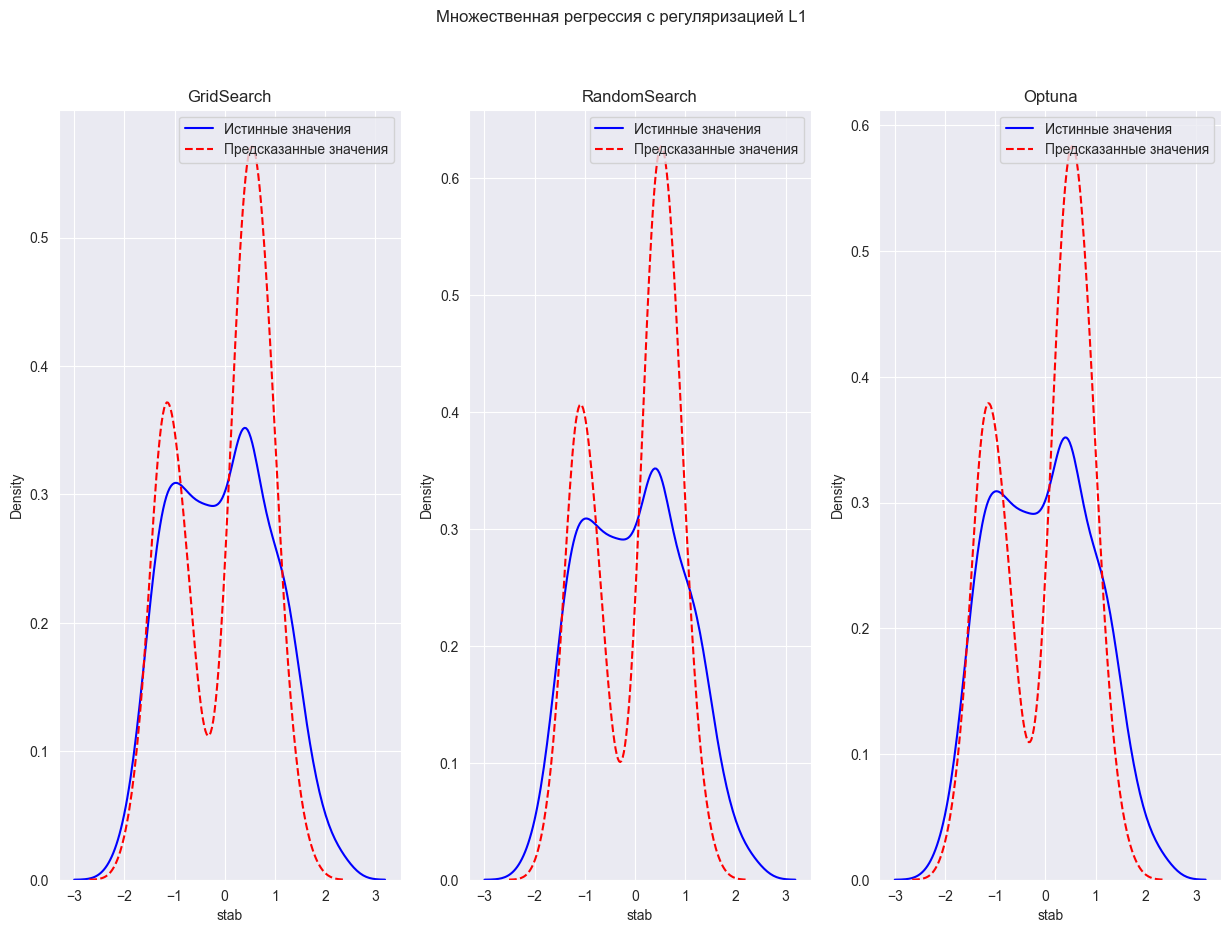

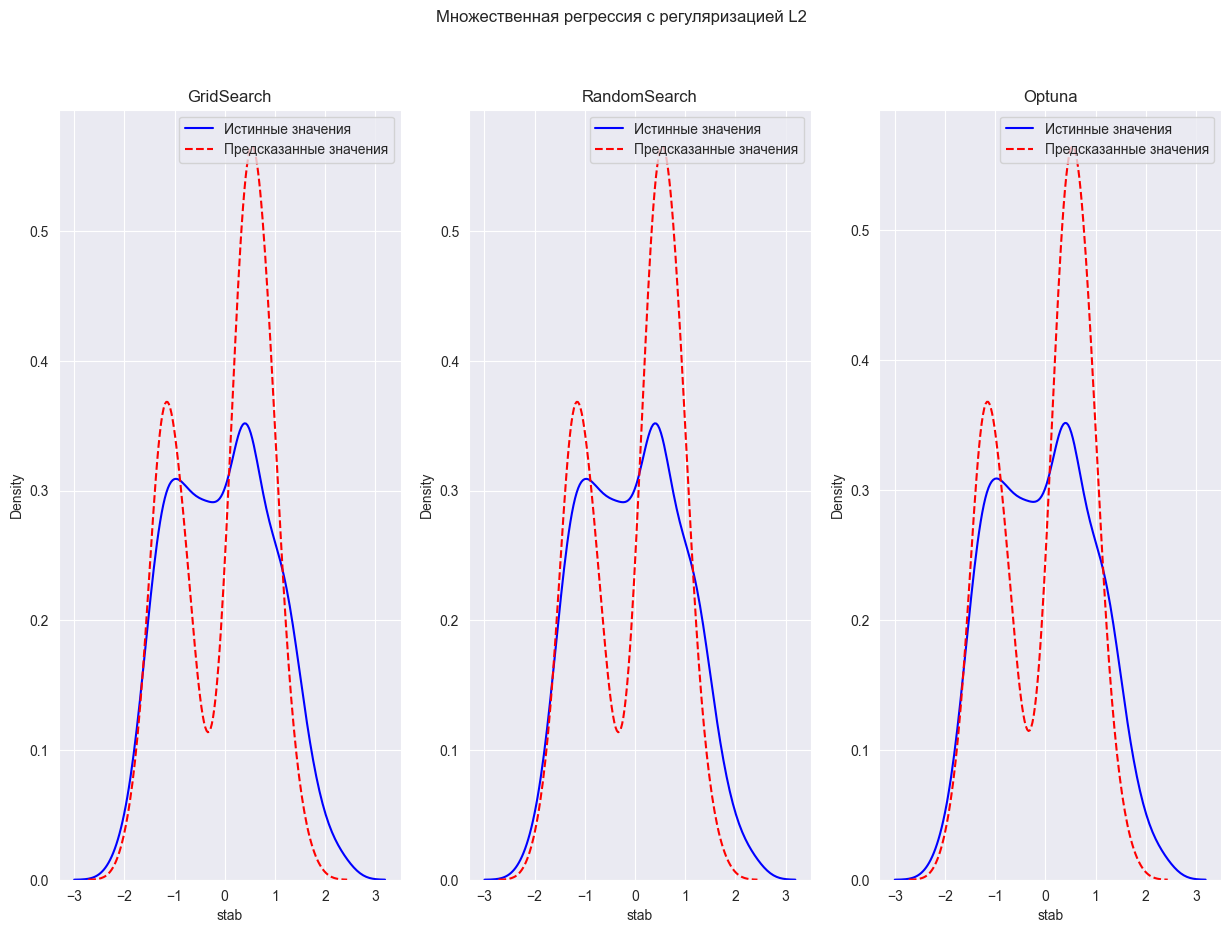

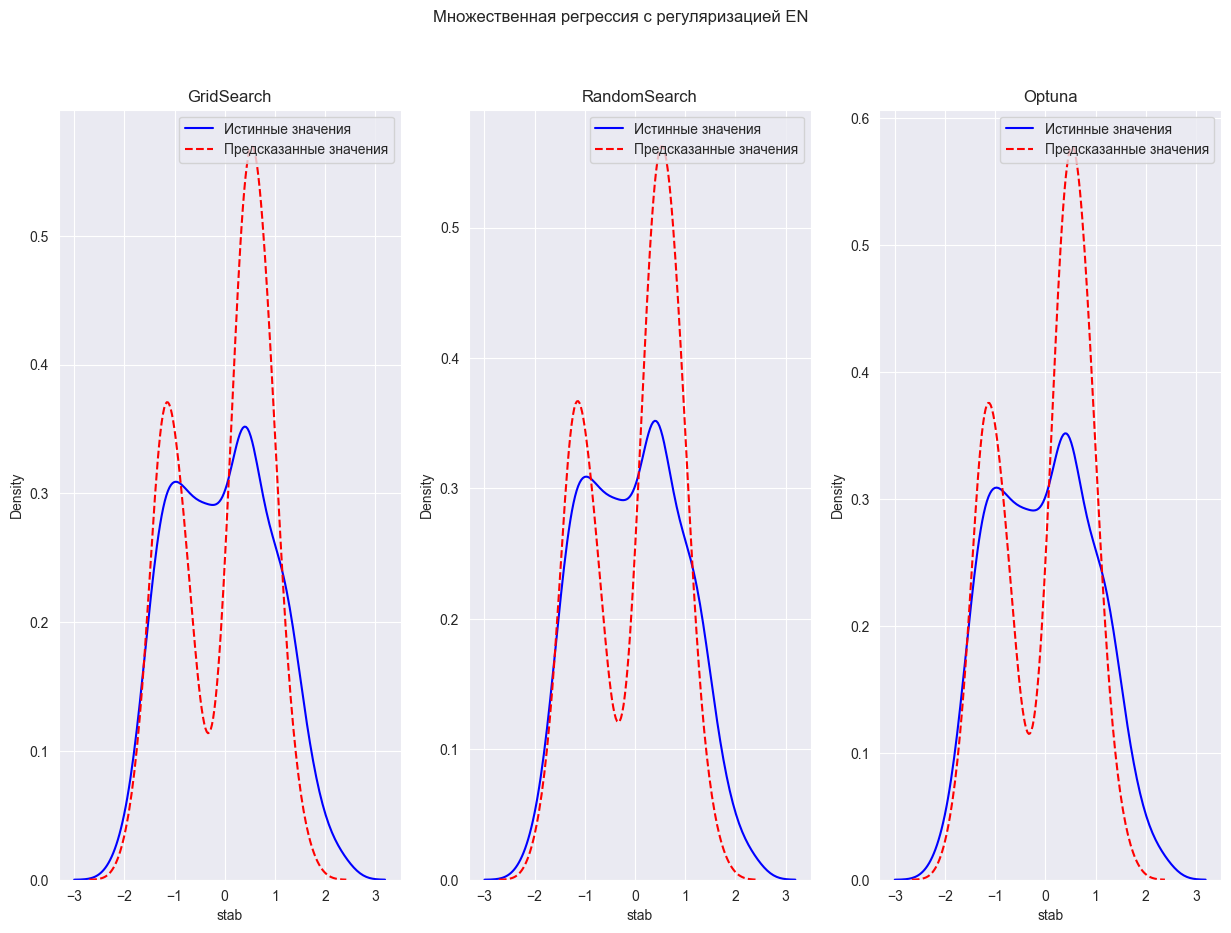

In [47]:
for name_of_reg, reg_info in multiple_model_reg.items():
    fig, axes = plt.subplots(1, 3, figsize=(15, 10))
    for (name_of_method, model_info), ax in zip(reg_info.items(), axes):
        model = model_info["model"]

        val_predict = model.predict(X_val)
        train_predict = model.predict(X_train)
        test_predict = model.predict(X_test)

        input_metrics_into_the_train_val_table(f"Multiple regression with {name_of_reg} ({name_of_method})",
                          train_predict, y_train,
                          val_predict, y_val)

        input_metrics_into_the_test_table(f"Multiple regression with {name_of_reg} ({name_of_method})", test_predict, y_test)

        sns.kdeplot(y_val, color="blue", label="Истинные значения", ax=ax)

        sns.kdeplot(val_predict, linestyle="--", color="red", label="Предсказанные значения", ax=ax)

        ax.grid(True)
        ax.legend()
        ax.set_title(name_of_method)

    plt.suptitle(f"Множественная регрессия c регуляризацией {name_of_reg}")



Визуально регуляризация практически никак не изменила модель. Посмотрим на метрики

In [48]:
train_and_val_metrics_comparing

,"(Train Data, R2)","(Train Data, MSE)","(Train Data, RMSE)","(Train Data, MAE)","(Train Data, MAPE)","(Val Data, R2)","(Val Data, MSE)","(Val Data, RMSE)","(Val Data, MAE)","(Val Data, MAPE)"
Multiple regression,0.82,0.1836,0.4284,0.3416,2.1711,0.81,0.1863,0.4317,0.3501,1.6128
Multiple regression with L1 (GridSearch),0.82,0.1836,0.4285,0.3417,2.1686,0.81,0.1859,0.4312,0.3497,1.6065
Multiple regression with L1 (RandomSearch),0.81,0.1872,0.4327,0.3463,2.1280,0.81,0.1873,0.4328,0.3504,1.5577
Multiple regression with L1 (Optuna),0.82,0.1840,0.4289,0.3423,2.1622,0.81,0.1856,0.4308,0.3493,1.5946
Multiple regression with L2 (GridSearch),0.82,0.1836,0.4284,0.3416,2.1696,0.81,0.1863,0.4317,0.3501,1.6120
Multiple regression with L2 (RandomSearch),0.82,0.1836,0.4284,0.3416,2.1696,0.81,0.1863,0.4317,0.3501,1.6120
Multiple regression with L2 (Optuna),0.82,0.1836,0.4284,0.3415,2.1653,0.81,0.1863,0.4317,0.3501,1.6097
Multiple regression with EN (GridSearch),0.82,0.1836,0.4285,0.3417,2.1610,0.81,0.1860,0.4313,0.3497,1.6029
Multiple regression with EN (RandomSearch),0.82,0.1837,0.4286,0.3414,2.1338,0.81,0.1863,0.4316,0.3501,1.5913
Multiple regression with EN (Optuna),0.82,0.1840,0.4289,0.3421,2.1402,0.81,0.1857,0.4309,0.3493,1.5830


В целом модель без регуляризации и модели с регуляризацией дали практически одинаковые результаты.

L1 регуляризация, параметры для которой были получены при помощи RandomSearch, немного ухудшило значение метрики MSE (с 0.1802 до 0.1835).

Модели с L2 регуляризацией и Elastic Net регуляризацией (параметры были получены с помощью Optuna) уменьшилили значение метрики MSE (с 0.1802 до 0.1798)

### Полиномиальная регрессия 2 степени без регуляризации

In [49]:
poly2 = PolynomialFeatures(degree=2)
X_poly2_train = poly2.fit_transform(X_train)

X_poly2_val = poly2.transform(X_val)
X_poly2_test = poly2.transform(X_test)

X_poly2_train.shape

(8000, 105)

In [50]:
poly2_model = LinearRegression()
poly2_model.fit(X_poly2_train, y_train)

poly2_train_predict = poly2_model.predict(X_poly2_train)
poly2_val_predict = poly2_model.predict(X_poly2_val)
poly2_test_predict = poly2_model.predict(X_poly2_test)

input_metrics_into_the_train_val_table(f"Polynomial regression (deg = 2)",
                          poly2_train_predict, y_train,
                          poly2_val_predict, y_val)

input_metrics_into_the_test_table(f"Polynomial regression (deg = 2)", poly2_test_predict, y_test)

train_and_val_metrics_comparing

,"(Train Data, R2)","(Train Data, MSE)","(Train Data, RMSE)","(Train Data, MAE)","(Train Data, MAPE)","(Val Data, R2)","(Val Data, MSE)","(Val Data, RMSE)","(Val Data, MAE)","(Val Data, MAPE)"
Multiple regression,0.82,0.1836,0.4284,0.3416,2.1711,0.81,0.1863,0.4317,0.3501,1.6128
Multiple regression with L1 (GridSearch),0.82,0.1836,0.4285,0.3417,2.1686,0.81,0.1859,0.4312,0.3497,1.6065
Multiple regression with L1 (RandomSearch),0.81,0.1872,0.4327,0.3463,2.1280,0.81,0.1873,0.4328,0.3504,1.5577
Multiple regression with L1 (Optuna),0.82,0.1840,0.4289,0.3423,2.1622,0.81,0.1856,0.4308,0.3493,1.5946
Multiple regression with L2 (GridSearch),0.82,0.1836,0.4284,0.3416,2.1696,0.81,0.1863,0.4317,0.3501,1.6120
Multiple regression with L2 (RandomSearch),0.82,0.1836,0.4284,0.3416,2.1696,0.81,0.1863,0.4317,0.3501,1.6120
Multiple regression with L2 (Optuna),0.82,0.1836,0.4284,0.3415,2.1653,0.81,0.1863,0.4317,0.3501,1.6097
Multiple regression with EN (GridSearch),0.82,0.1836,0.4285,0.3417,2.1610,0.81,0.1860,0.4313,0.3497,1.6029
Multiple regression with EN (RandomSearch),0.82,0.1837,0.4286,0.3414,2.1338,0.81,0.1863,0.4316,0.3501,1.5913
Multiple regression with EN (Optuna),0.82,0.1840,0.4289,0.3421,2.1402,0.81,0.1857,0.4309,0.3493,1.5830


Text(0.5, 1.0, 'Полиномиальная регрессия 2 степени без регуляризации')

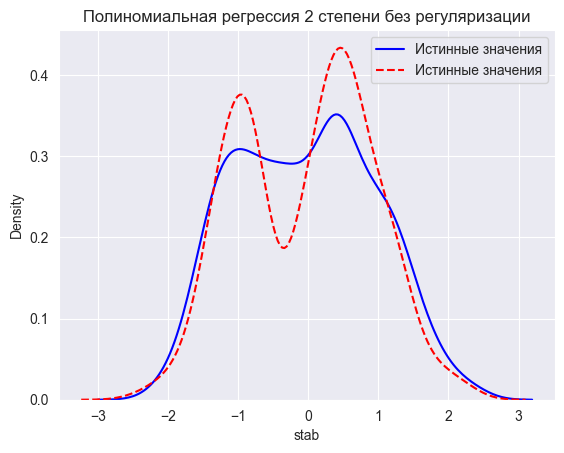

In [51]:
sns.kdeplot(y_val, color="blue", label="Истинные значения")
sns.kdeplot(poly2_val_predict, color="red", label="Истинные значения", linestyle="--")

plt.legend()
plt.grid(True)
plt.title("Полиномиальная регрессия 2 степени без регуляризации")

Полиномиальная регрессия 2 степени показала себя лучше, чем модели с линейными зависимостями (коэффициент R2 вырос до 0.92). Значения прочих метрик уменьшились - например, метрика RMSE равна 0.0827.

Стоит отметить, что на валидационной выборке значения метрик немного хуже, чем на тренировочной. Так, R2 на валидационной выборке равен 0.92, а на тренировочной 0.93. На тренировочной выборке MAE равен 0.2057, а на валидационной 0.2171. Разница не достататочно велика для того, чтобы говорить о наличии переобучения в модели.

### Полиномиальная регрессия 3 степени без регуляризации

In [52]:
poly3 = PolynomialFeatures(degree=3)
X_poly3_train = poly3.fit_transform(X_train)

X_poly3_val = poly3.transform(X_val)
X_poly3_test = poly3.transform(X_test)

X_poly3_train.shape

(8000, 560)

In [53]:
poly3_model = LinearRegression()
poly3_model.fit(X_poly3_train, y_train)

poly3_train_predict = poly3_model.predict(X_poly3_train)
poly3_val_predict = poly3_model.predict(X_poly3_val)
poly3_test_predict = poly3_model.predict(X_poly3_test)

input_metrics_into_the_train_val_table(f"Polynomial regression (deg = 3)",
                          poly3_train_predict, y_train,
                          poly3_val_predict, y_val)

input_metrics_into_the_test_table(f"Polynomial regression (deg = 2)", poly3_test_predict, y_test)

train_and_val_metrics_comparing

,"(Train Data, R2)","(Train Data, MSE)","(Train Data, RMSE)","(Train Data, MAE)","(Train Data, MAPE)","(Val Data, R2)","(Val Data, MSE)","(Val Data, RMSE)","(Val Data, MAE)","(Val Data, MAPE)"
Multiple regression,0.82,0.1836,0.4284,0.3416,2.1711,0.81,0.1863,0.4317,0.3501,1.6128
Multiple regression with L1 (GridSearch),0.82,0.1836,0.4285,0.3417,2.1686,0.81,0.1859,0.4312,0.3497,1.6065
Multiple regression with L1 (RandomSearch),0.81,0.1872,0.4327,0.3463,2.1280,0.81,0.1873,0.4328,0.3504,1.5577
Multiple regression with L1 (Optuna),0.82,0.1840,0.4289,0.3423,2.1622,0.81,0.1856,0.4308,0.3493,1.5946
Multiple regression with L2 (GridSearch),0.82,0.1836,0.4284,0.3416,2.1696,0.81,0.1863,0.4317,0.3501,1.6120
Multiple regression with L2 (RandomSearch),0.82,0.1836,0.4284,0.3416,2.1696,0.81,0.1863,0.4317,0.3501,1.6120
Multiple regression with L2 (Optuna),0.82,0.1836,0.4284,0.3415,2.1653,0.81,0.1863,0.4317,0.3501,1.6097
Multiple regression with EN (GridSearch),0.82,0.1836,0.4285,0.3417,2.1610,0.81,0.1860,0.4313,0.3497,1.6029
Multiple regression with EN (RandomSearch),0.82,0.1837,0.4286,0.3414,2.1338,0.81,0.1863,0.4316,0.3501,1.5913
Multiple regression with EN (Optuna),0.82,0.1840,0.4289,0.3421,2.1402,0.81,0.1857,0.4309,0.3493,1.5830


Text(0.5, 1.0, 'Полиномиальная регрессия 3 степени без регуляризации')

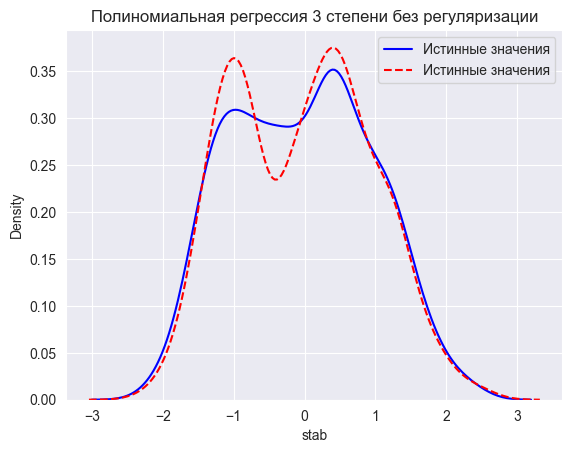

In [54]:
sns.kdeplot(y_val, color="blue", label="Истинные значения")
sns.kdeplot(poly3_val_predict, color="red", label="Истинные значения", linestyle="--")

plt.legend()
plt.grid(True)
plt.title("Полиномиальная регрессия 3 степени без регуляризации")

Полиномиальная регрессия 3 степени показала себя еще лучше, чем полиномиальная регрессия 2 степени (коэффициент R2 вырос до 0.97 на тренировочных данных и до 0.96 на валидационных).

### Полиномиальная регрессия 4 степени без регуляризации

In [55]:
poly4 = PolynomialFeatures(degree=4)
X_poly4_train = poly4.fit_transform(X_train)

X_poly4_val = poly4.transform(X_val)
X_poly4_test = poly4.transform(X_test)

X_poly4_train.shape

(8000, 2380)

In [56]:
poly4_model = LinearRegression()
poly4_model.fit(X_poly4_train, y_train)

poly4_train_predict = poly4_model.predict(X_poly4_train)
poly4_val_predict = poly4_model.predict(X_poly4_val)
poly4_test_predict = poly4_model.predict(X_poly4_test)

input_metrics_into_the_train_val_table(f"Polynomial regression (deg = 4)",
                          poly4_train_predict, y_train,
                          poly4_val_predict, y_val)

input_metrics_into_the_test_table(f"Polynomial regression (deg = 4)", poly4_test_predict, y_test)

train_and_val_metrics_comparing

,"(Train Data, R2)","(Train Data, MSE)","(Train Data, RMSE)","(Train Data, MAE)","(Train Data, MAPE)","(Val Data, R2)","(Val Data, MSE)","(Val Data, RMSE)","(Val Data, MAE)","(Val Data, MAPE)"
Multiple regression,0.82,0.1836,0.4284,0.3416,2.1711,0.81,0.1863,0.4317,0.3501,1.6128
Multiple regression with L1 (GridSearch),0.82,0.1836,0.4285,0.3417,2.1686,0.81,0.1859,0.4312,0.3497,1.6065
Multiple regression with L1 (RandomSearch),0.81,0.1872,0.4327,0.3463,2.1280,0.81,0.1873,0.4328,0.3504,1.5577
Multiple regression with L1 (Optuna),0.82,0.1840,0.4289,0.3423,2.1622,0.81,0.1856,0.4308,0.3493,1.5946
Multiple regression with L2 (GridSearch),0.82,0.1836,0.4284,0.3416,2.1696,0.81,0.1863,0.4317,0.3501,1.6120
Multiple regression with L2 (RandomSearch),0.82,0.1836,0.4284,0.3416,2.1696,0.81,0.1863,0.4317,0.3501,1.6120
Multiple regression with L2 (Optuna),0.82,0.1836,0.4284,0.3415,2.1653,0.81,0.1863,0.4317,0.3501,1.6097
Multiple regression with EN (GridSearch),0.82,0.1836,0.4285,0.3417,2.1610,0.81,0.1860,0.4313,0.3497,1.6029
Multiple regression with EN (RandomSearch),0.82,0.1837,0.4286,0.3414,2.1338,0.81,0.1863,0.4316,0.3501,1.5913
Multiple regression with EN (Optuna),0.82,0.1840,0.4289,0.3421,2.1402,0.81,0.1857,0.4309,0.3493,1.5830


Полиномиальная регрессия 4 степени показала себя лучше прочих моделей на тренировочной и валидационной выборках.

Стоит отметить, что на тренировочных данных модель показывает лучшие метрики, чем на валидационной выборке. Так, коэффициент R2 равен 0.98 на тренировочных данных и 0.96 на валидационных. Метрика RMSE равна 0.1322 на тренировочных данных и 0.2025 на валидационных. Это говорит о переобучении модели.

Text(0.5, 1.0, 'Полиномиальная регрессия 4 степени без регуляризации')

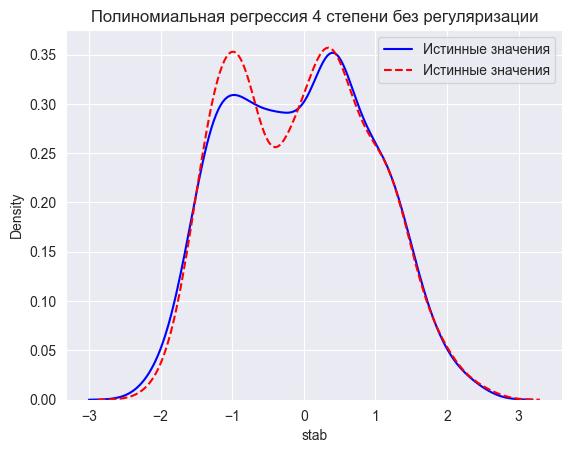

In [57]:
sns.kdeplot(y_val, color="blue", label="Истинные значения")
sns.kdeplot(poly4_val_predict, color="red", label="Истинные значения", linestyle="--")

plt.legend()
plt.grid(True)
plt.title("Полиномиальная регрессия 4 степени без регуляризации")

### Полиномиальные модели с регуляризацией

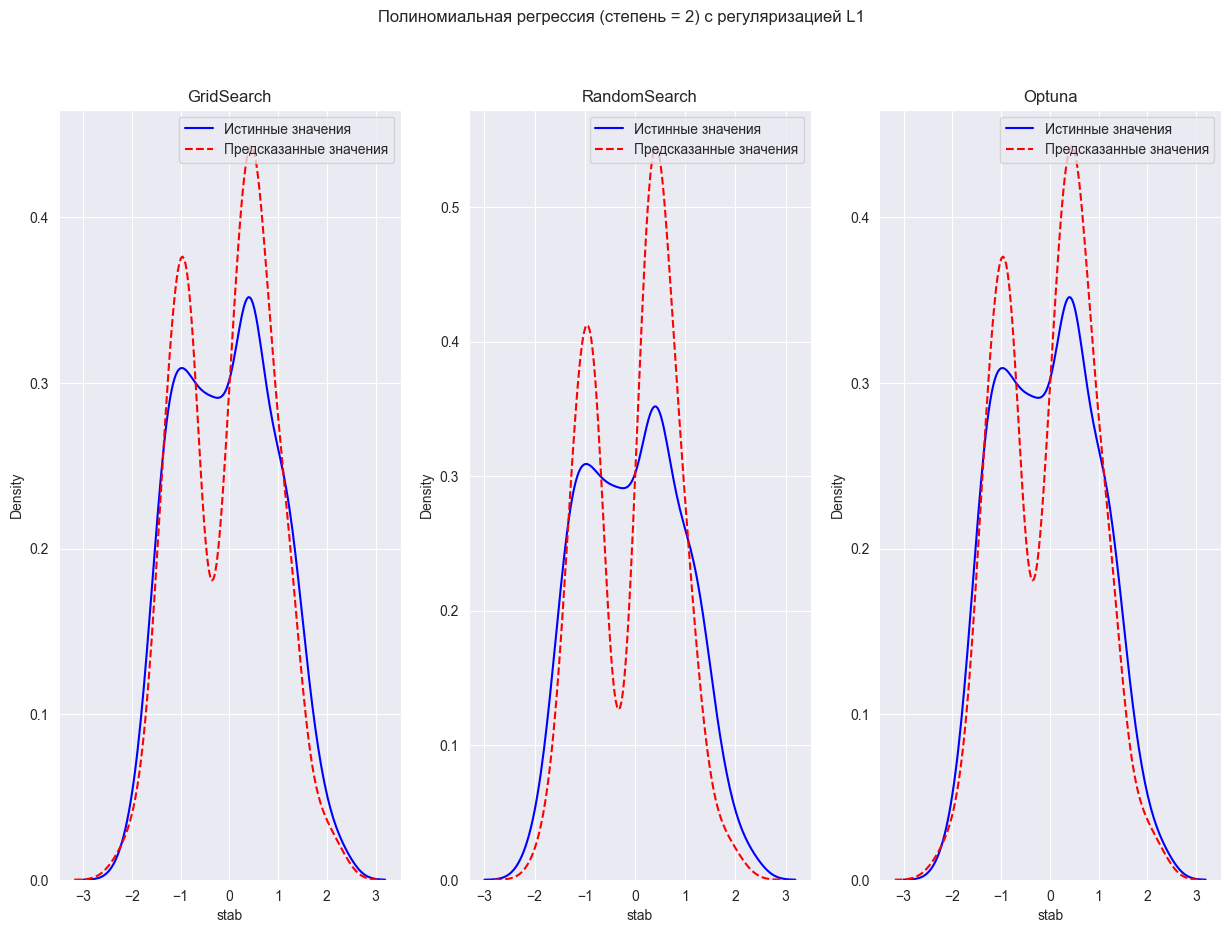

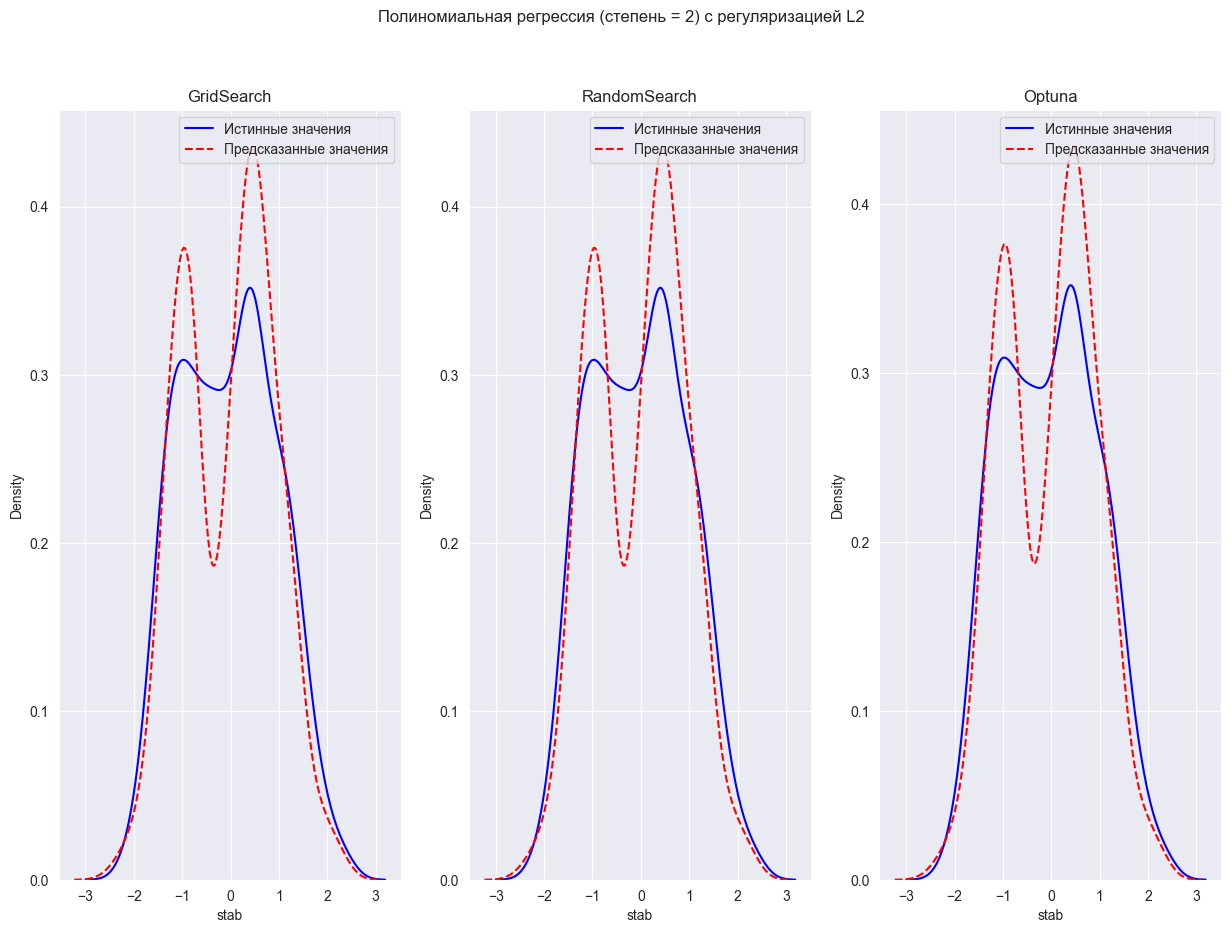

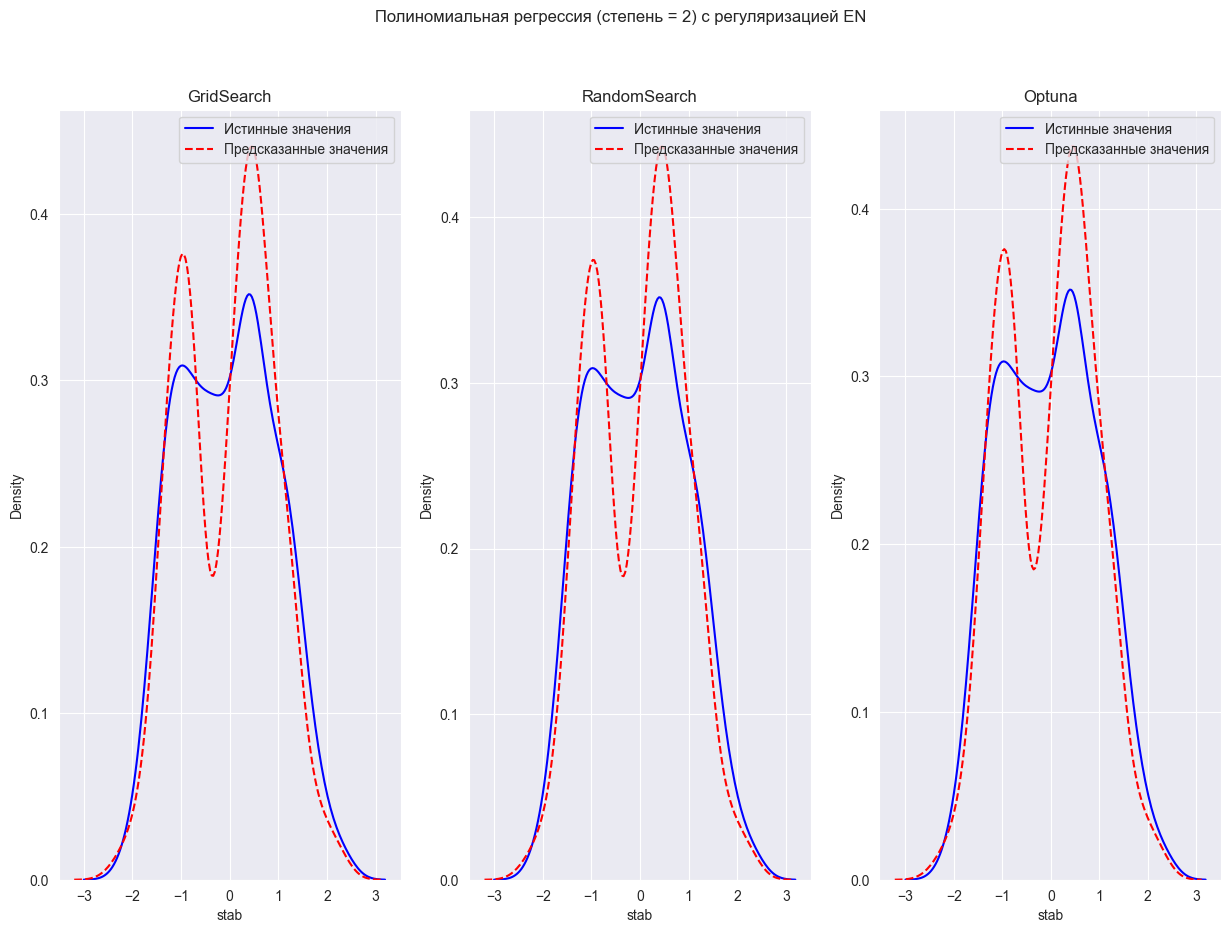

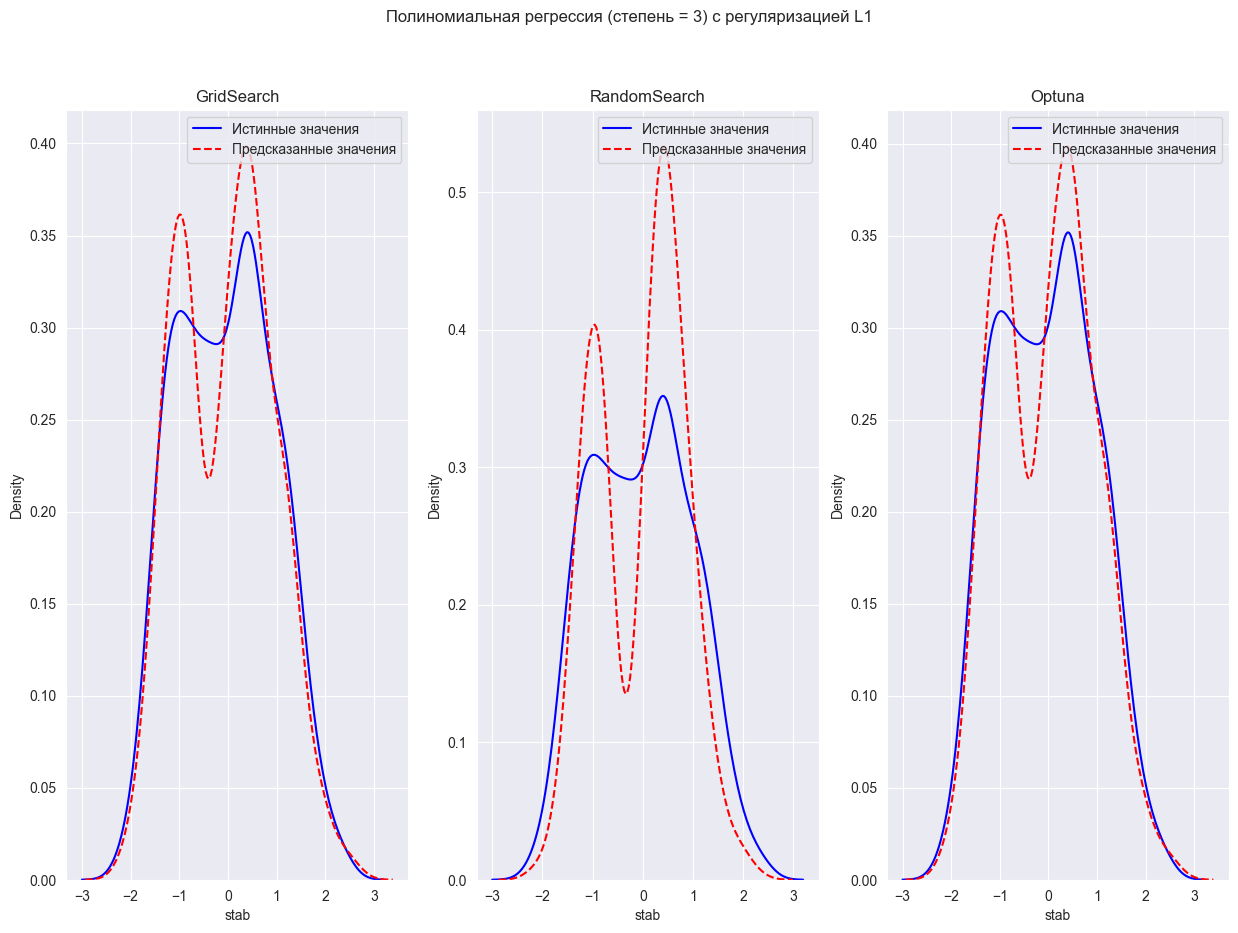

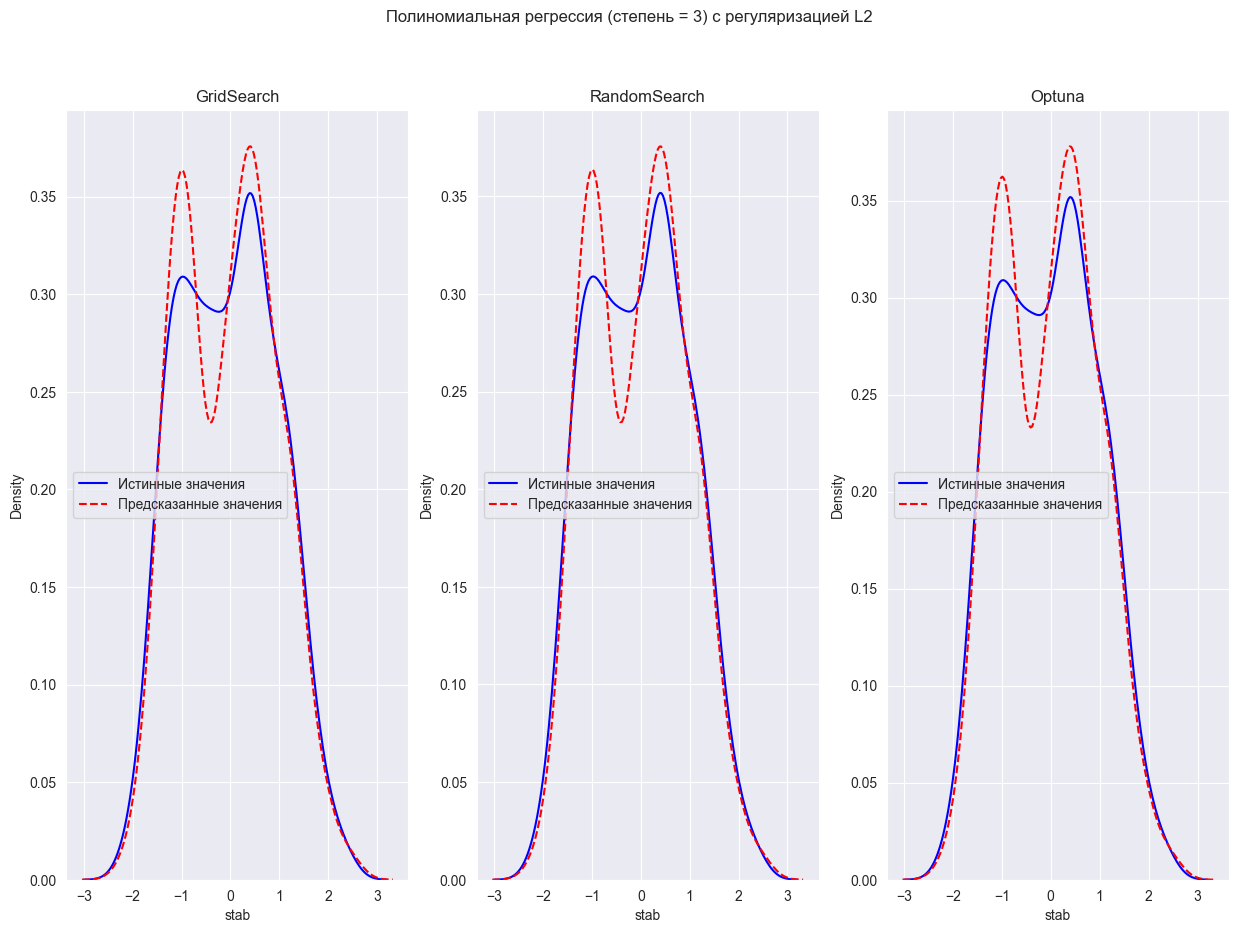

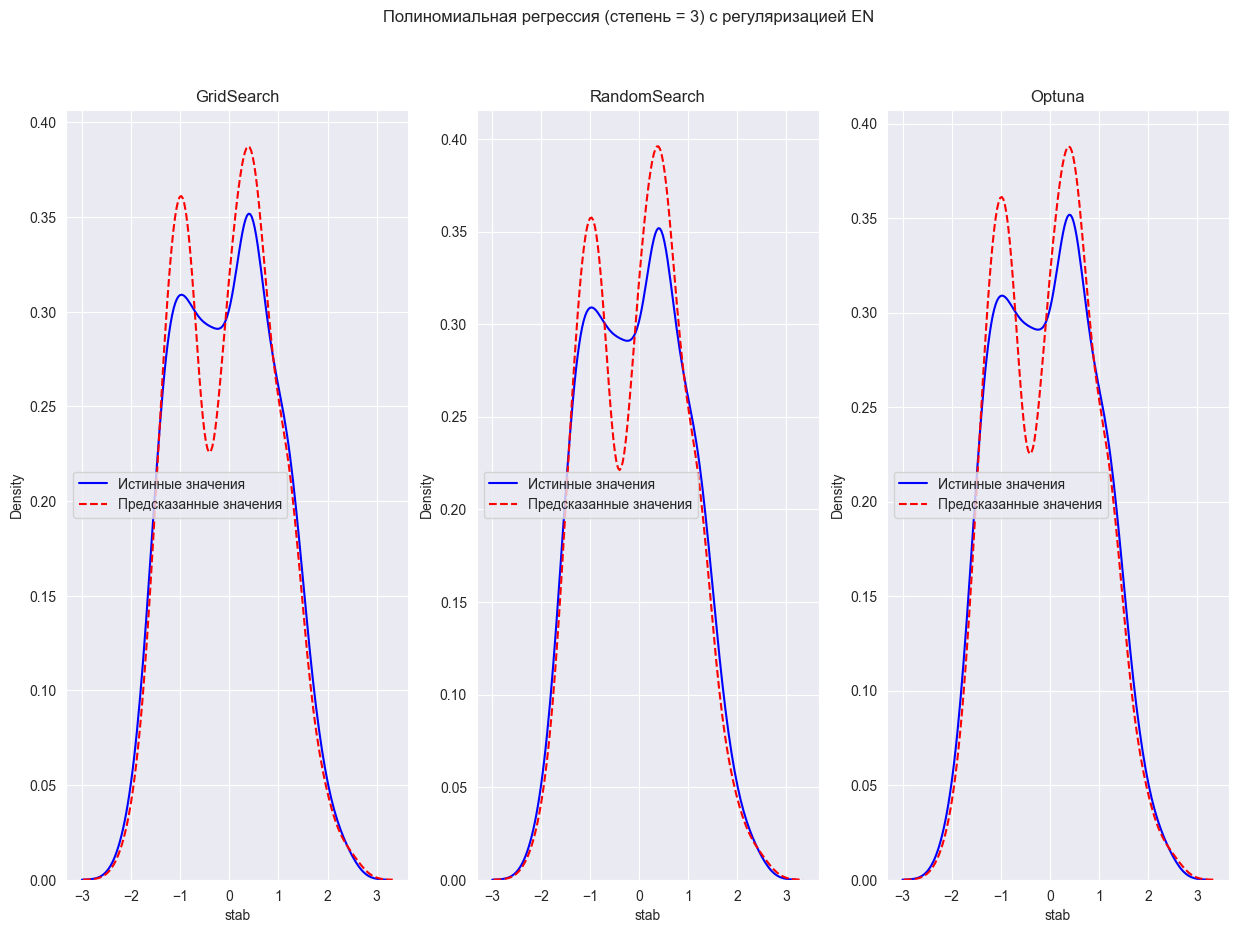

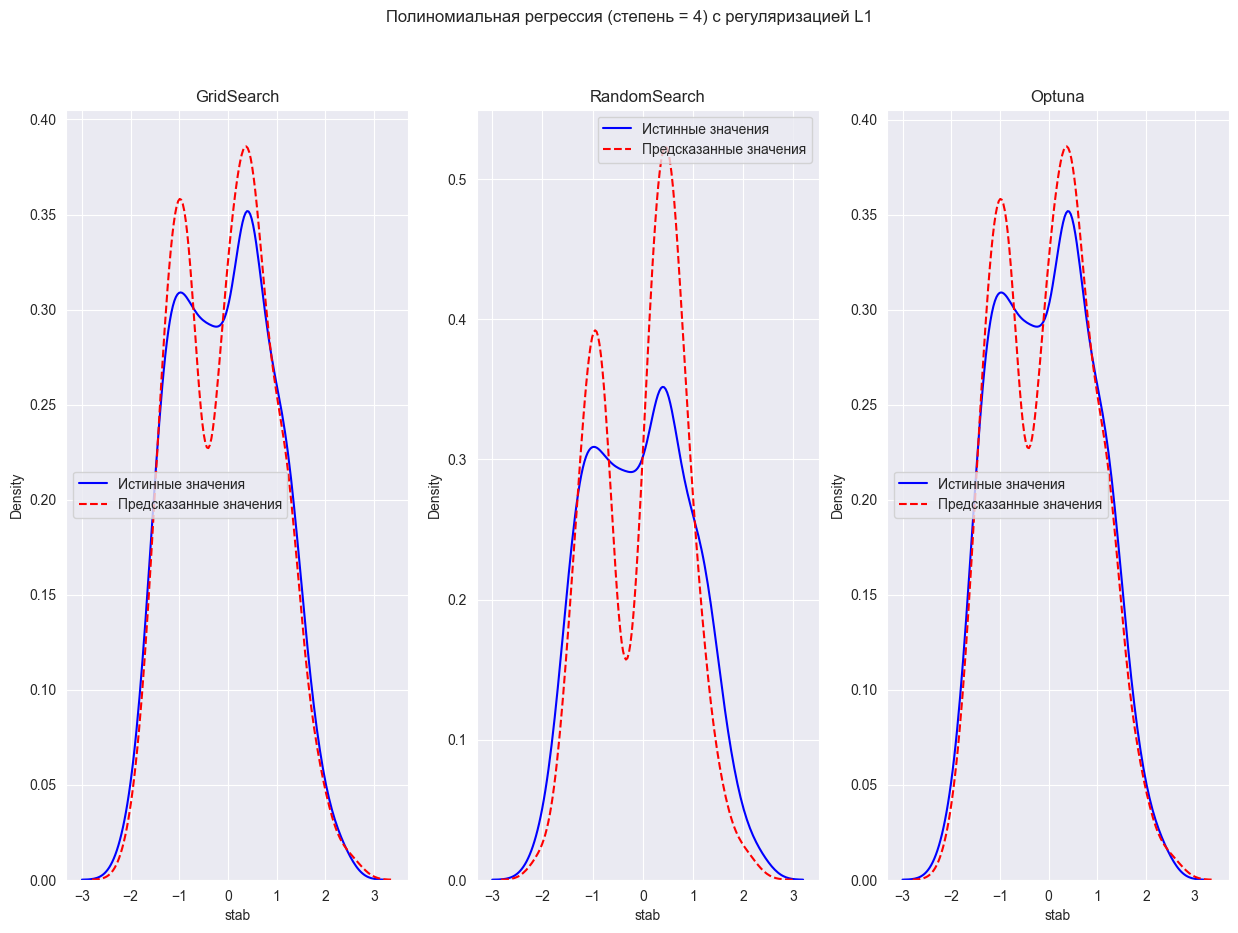

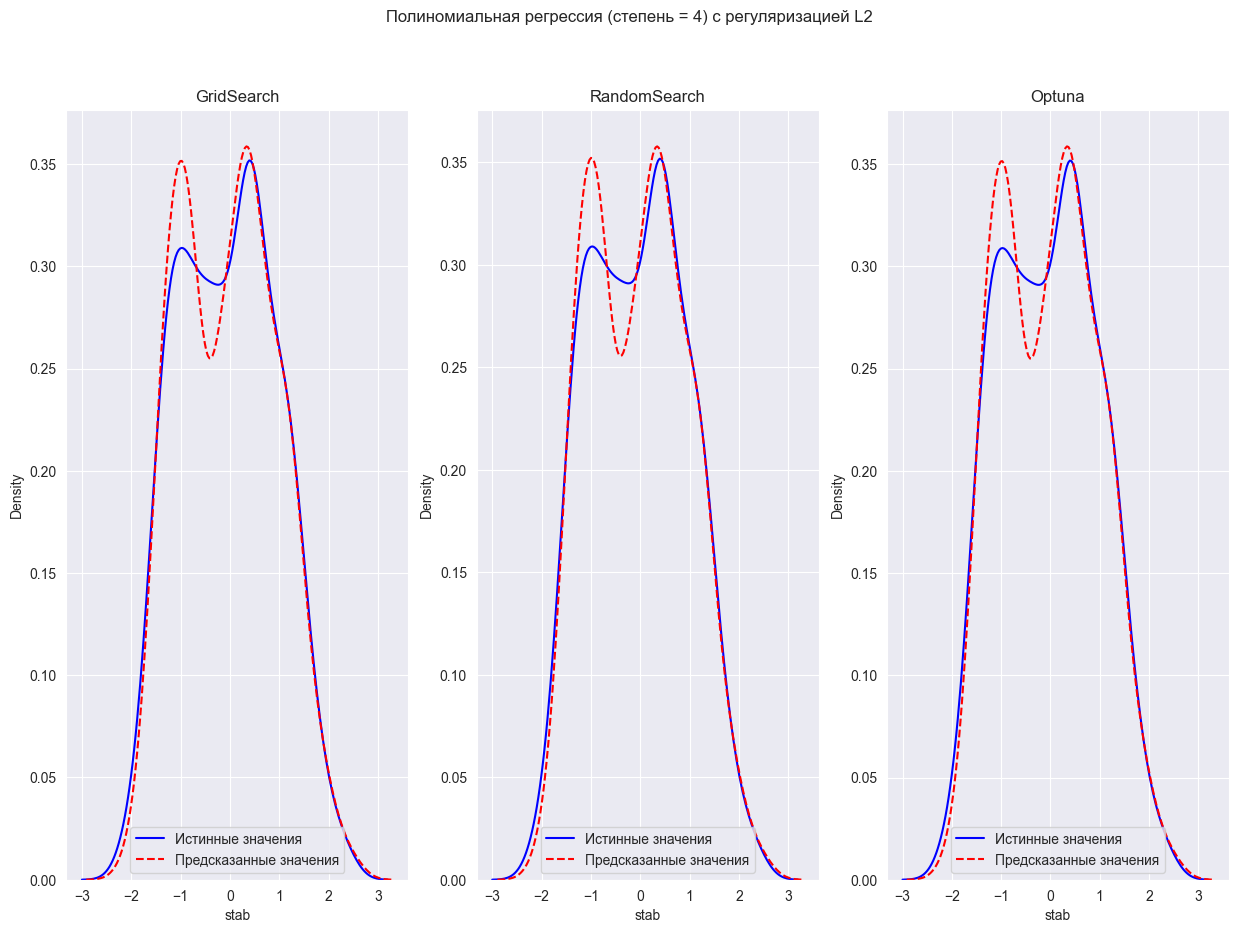

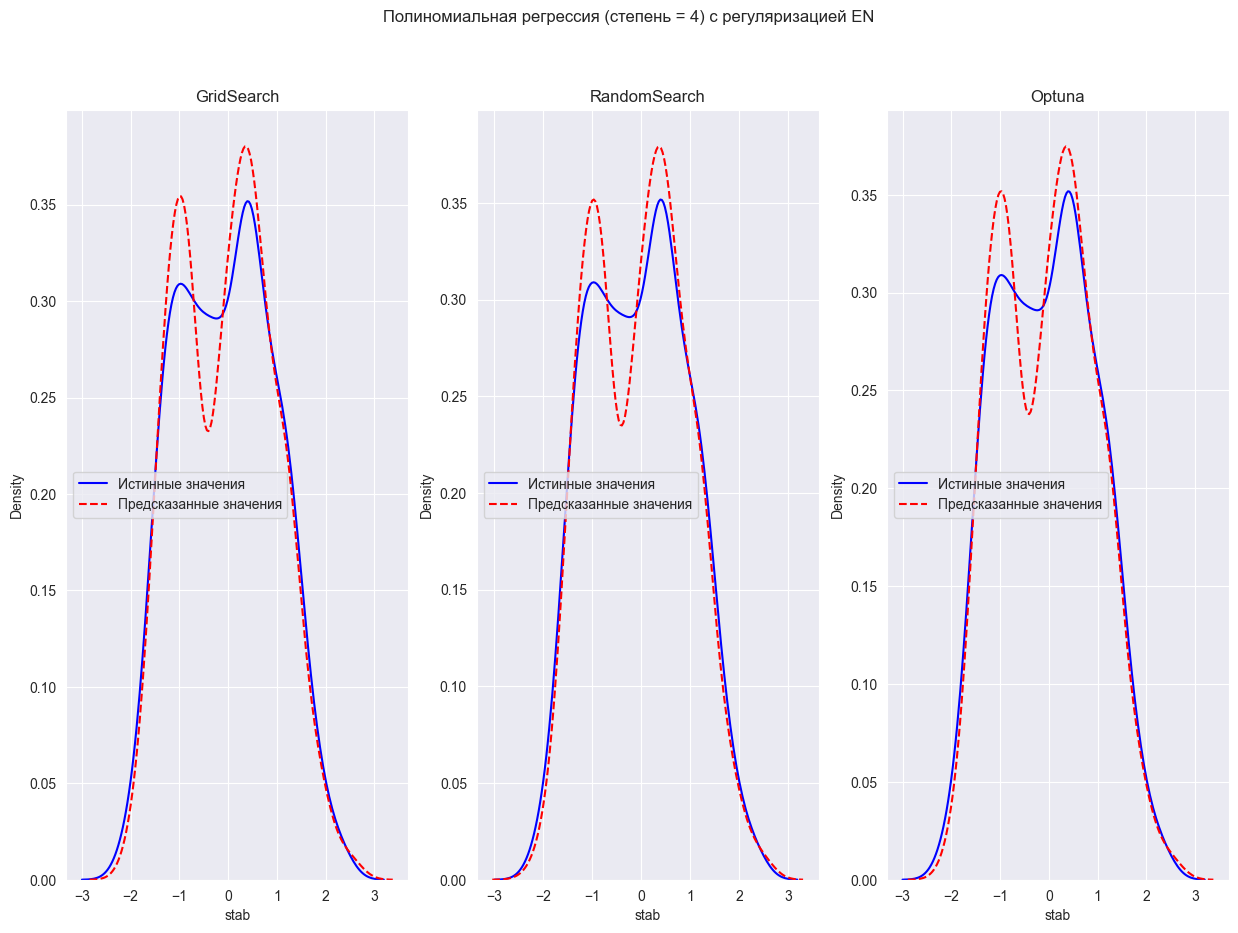

In [59]:
polynomial_data = [(X_poly2_train, X_poly2_val, X_poly2_test), (X_poly3_train, X_poly3_val, X_poly3_test), (X_poly4_train, X_poly4_val, X_poly4_test)]
poly_models_info = {}

for degree, (train, val, test) in enumerate(polynomial_data, start=2):
    poly_models_info[degree] = train_models_with_reg(train, y_train, val, y_val, reg_config)
    polynomial_model_reg = poly_models_info[degree]
    for name_of_reg, reg_info in polynomial_model_reg.items():
        fig, axes = plt.subplots(1, 3, figsize=(15, 10))

        for (name_of_method, model_info), ax in zip(reg_info.items(), axes):
            model = model_info["model"]

            val_predict = model.predict(val)
            train_predict = model.predict(train)
            test_predict = model.predict(test)

            name_of_model = f"Polynomial regression (deg = {degree}) with {name_of_reg} ({name_of_method})"
            input_metrics_into_the_train_val_table(name_of_model,  train_predict, y_train, val_predict, y_val)

            input_metrics_into_the_test_table(name_of_model, test_predict, y_test)

            sns.kdeplot(y_val, color="blue", label="Истинные значения", ax=ax)

            sns.kdeplot(val_predict, linestyle="--", color="red", label="Предсказанные значения", ax=ax)

            ax.grid(True)
            ax.legend()
            ax.set_title(name_of_method)

        plt.suptitle(f"Полиномиальная регрессия (степень = {degree}) c регуляризацией {name_of_reg}")



In [65]:
train_and_val_metrics_comparing[train_and_val_metrics_comparing.index.str.startswith("Polynomial")]

,"(Train Data, R2)","(Train Data, MSE)","(Train Data, RMSE)","(Train Data, MAE)","(Train Data, MAPE)","(Val Data, R2)","(Val Data, MSE)","(Val Data, RMSE)","(Val Data, MAE)","(Val Data, MAPE)"
Polynomial regression (deg = 2),0.93,0.0725,0.2693,0.2036,1.0863,0.92,0.0751,0.2740,0.2102,0.8099
Polynomial regression (deg = 3),0.97,0.0335,0.1831,0.1276,0.6057,0.96,0.0395,0.1987,0.1393,0.3883
Polynomial regression (deg = 4),0.98,0.0178,0.1334,0.0913,0.4005,0.97,0.0337,0.1836,0.1236,0.3396
Polynomial regression (deg = 2) with L1 (GridSearch),0.93,0.0728,0.2697,0.2041,1.0792,0.92,0.0752,0.2742,0.2108,0.8067
Polynomial regression (deg = 2) with L1 (RandomSearch),0.91,0.0921,0.3035,0.2383,1.2805,0.90,0.0941,0.3068,0.2420,0.9165
Polynomial regression (deg = 2) with L1 (Optuna),0.93,0.0728,0.2697,0.2041,1.0792,0.92,0.0752,0.2742,0.2108,0.8067
Polynomial regression (deg = 2) with L2 (GridSearch),0.93,0.0725,0.2693,0.2037,1.0832,0.92,0.0751,0.2740,0.2103,0.8091
Polynomial regression (deg = 2) with L2 (RandomSearch),0.93,0.0725,0.2693,0.2037,1.0832,0.92,0.0751,0.2740,0.2103,0.8091
Polynomial regression (deg = 2) with L2 (Optuna),0.93,0.0725,0.2693,0.2036,1.0863,0.92,0.0751,0.2740,0.2102,0.8099
Polynomial regression (deg = 2) with EN (GridSearch),0.93,0.0726,0.2695,0.2039,1.0804,0.92,0.0751,0.2741,0.2106,0.8074


После применения регуляризации лучшей моделью осталась полиномиальная модель 4 степени. В целом регуляризация практически никак не улучшила значения метрик на валидационных данных: наиболее сильное положительное влияние оказала регуляризация Elastic Net, так с ее применением метрика RMSE уменьшилась до 0.179.

### SGD регрессор

In [73]:
sgd_regressor = SGDRegressor()
sgd_regressor.fit(X_train, y_train)

train_predict = sgd_regressor.predict(X_train)
val_predict = sgd_regressor.predict(X_val)
test_predict = sgd_regressor.predict(X_test)

input_metrics_into_the_train_val_table("SGD regression",
                          train_predict, y_train,
                          val_predict, y_val)

input_metrics_into_the_test_table(f"SGD regression", test_predict, y_test)

Text(0.5, 1.0, 'SGD регрессия без регуляризации')

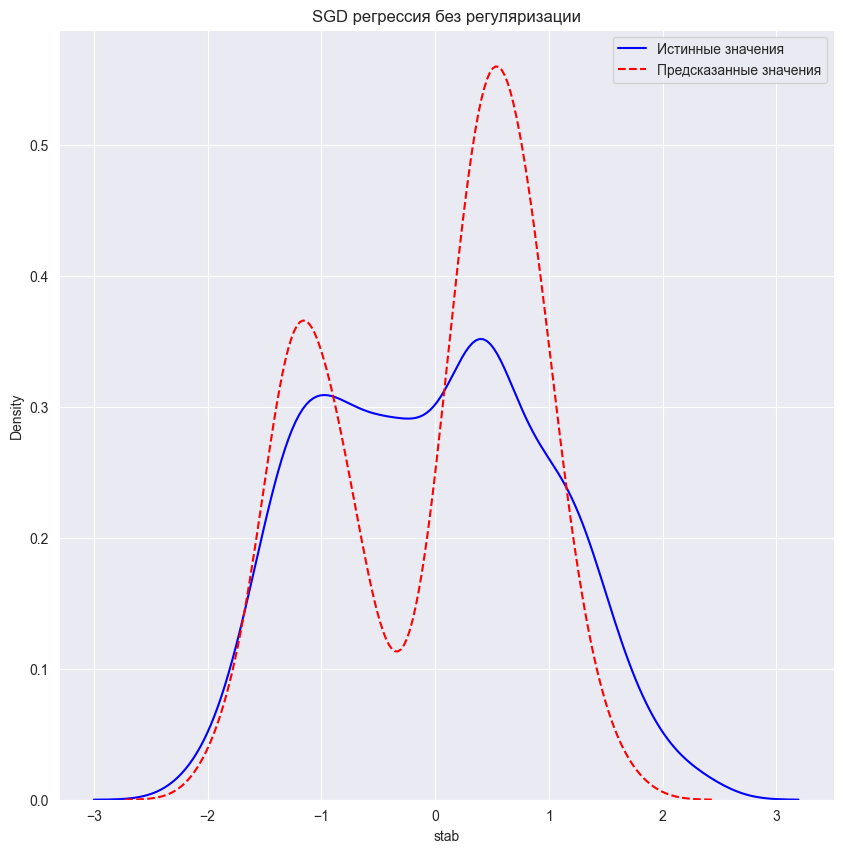

In [74]:
plt.figure(figsize=(10, 10))

sns.kdeplot(y_val, color="blue", label="Истинные значения")

sns.kdeplot(val_predict, linestyle="--", color="red", label="Предсказанные значения")

plt.grid(True)
plt.legend()
plt.title("SGD регрессия без регуляризации")

In [77]:
train_and_val_metrics_comparing.loc["SGD regression"]

(Train Data, R2)      0.8200
(Train Data, MSE)     0.1840
(Train Data, RMSE)    0.4289
(Train Data, MAE)     0.3416
(Train Data, MAPE)    2.1408
(Val Data, R2)        0.8100
(Val Data, MSE)       0.1869
(Val Data, RMSE)      0.4324
(Val Data, MAE)       0.3509
(Val Data, MAPE)      1.6143
Name: SGD regression, dtype: float64

В целом SGD регрессор неплохо работает, но его метрики хуже метрик для полиномиальной регрессии

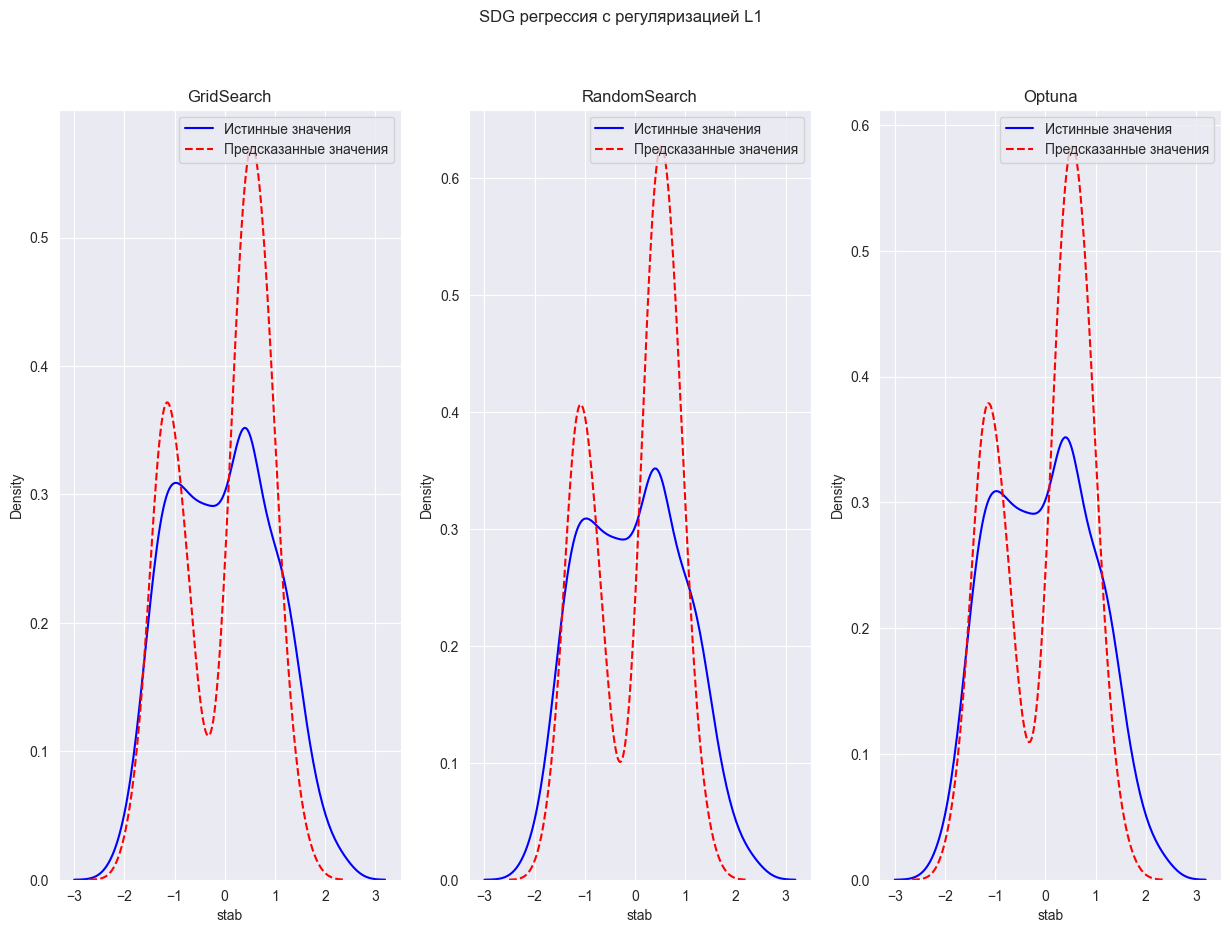

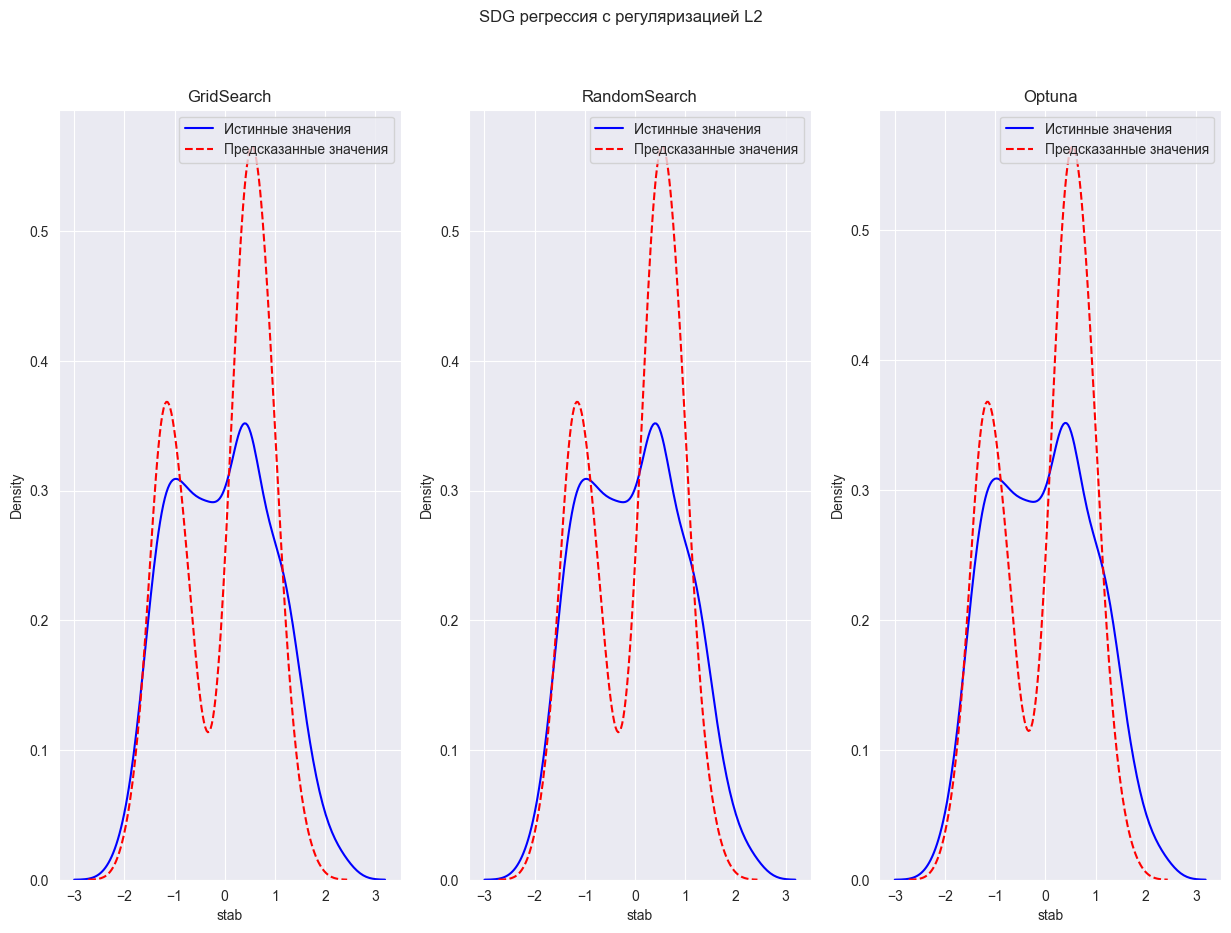

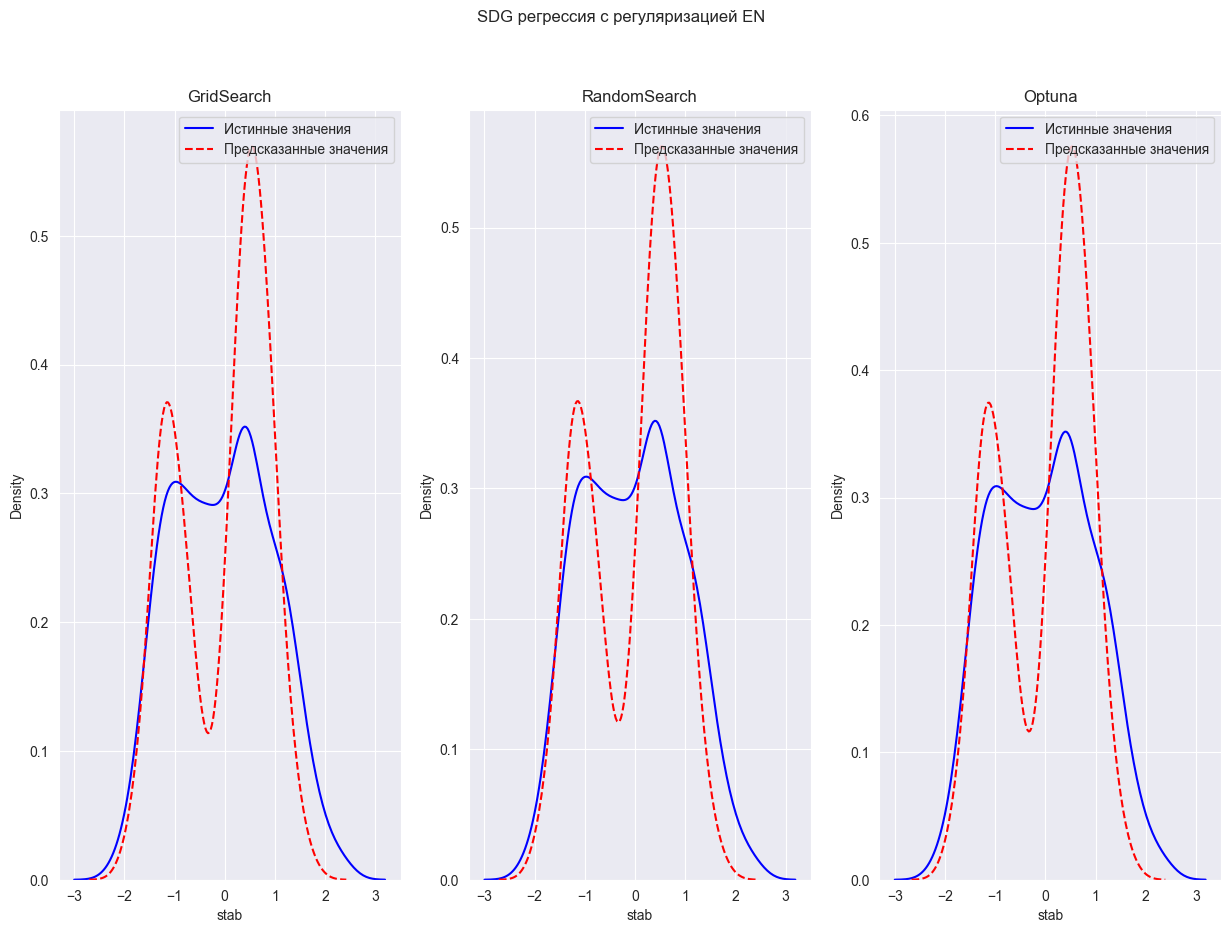

In [79]:
sgd_config = {"SGD": {
        "reg": SGDRegressor,
        "param_grid": {
            "penalty": ["l1", "l2", "elasticnet"],
            "alpha": alpha_range,
            "l1_ratio": [0.1, 0.5, 0.7],
            "learning_rate": ["constant", "adaptive"],
            "eta0": [0.001, 0.01],
            "max_iter": [1000],
        }
    }
}
sdg_models = train_models_with_reg(X_train, y_train, X_val, y_val, reg_config)

for name_of_reg, reg_info in sdg_models.items():
    fig, axes = plt.subplots(1, 3, figsize=(15, 10))
    for (name_of_method, model_info), ax in zip(reg_info.items(), axes):
        model = model_info["model"]

        val_predict = model.predict(X_val)
        train_predict = model.predict(X_train)
        test_predict = model.predict(X_test)

        input_metrics_into_the_train_val_table(f"SDG regression with {name_of_reg} ({name_of_method})",
                          train_predict, y_train,
                          val_predict, y_val)

        input_metrics_into_the_test_table(f"SDG regression with {name_of_reg} ({name_of_method})", test_predict, y_test)

        sns.kdeplot(y_val, color="blue", label="Истинные значения", ax=ax)

        sns.kdeplot(val_predict, linestyle="--", color="red", label="Предсказанные значения", ax=ax)

        ax.grid(True)
        ax.legend()
        ax.set_title(name_of_method)

    plt.suptitle(f"SDG регрессия c регуляризацией {name_of_reg}")


In [80]:
train_and_val_metrics_comparing[train_and_val_metrics_comparing.index.str.startswith("SGD")]

,"(Train Data, R2)","(Train Data, MSE)","(Train Data, RMSE)","(Train Data, MAE)","(Train Data, MAPE)","(Val Data, R2)","(Val Data, MSE)","(Val Data, RMSE)","(Val Data, MAE)","(Val Data, MAPE)"
SGD regression,0.82,0.1840,0.4289,0.3416,2.1408,0.81,0.1869,0.4324,0.3509,1.6143
SGD regression with L1 (GridSearch),0.82,0.1836,0.4285,0.3417,2.1686,0.81,0.1859,0.4312,0.3497,1.6065
SGD regression with L1 (RandomSearch),0.81,0.1872,0.4327,0.3463,2.1280,0.81,0.1873,0.4328,0.3504,1.5577
SGD regression with L1 (Optuna),0.82,0.1840,0.4289,0.3423,2.1622,0.81,0.1856,0.4308,0.3493,1.5946
SGD regression with L2 (GridSearch),0.82,0.1836,0.4284,0.3416,2.1696,0.81,0.1863,0.4317,0.3501,1.6120
SGD regression with L2 (RandomSearch),0.82,0.1836,0.4284,0.3416,2.1696,0.81,0.1863,0.4317,0.3501,1.6120
SGD regression with L2 (Optuna),0.82,0.1836,0.4284,0.3415,2.1653,0.81,0.1863,0.4317,0.3501,1.6097
SGD regression with EN (GridSearch),0.82,0.1836,0.4285,0.3417,2.1610,0.81,0.1860,0.4313,0.3497,1.6029
SGD regression with EN (RandomSearch),0.82,0.1837,0.4286,0.3414,2.1338,0.81,0.1863,0.4316,0.3501,1.5913
SGD regression with EN (Optuna),0.82,0.1840,0.4289,0.3421,2.1402,0.81,0.1857,0.4309,0.3493,1.5830


Настройка гиперпараметров никак не повлияла на качество модели с SGD регрессией.

Взглянем на значения метрик на тестовых данных

In [81]:
test_metrics_info

Test Data                  \
                                                          R2     MSE    RMSE   
Multiple regression                                     0.81  0.1932  0.4396   
Multiple regression with L1 (GridSearch)                0.81  0.1933  0.4397   
Multiple regression with L1 (RandomSearch)              0.81  0.1981  0.4451   
Multiple regression with L1 (Optuna)                    0.81  0.1938  0.4403   
Multiple regression with L2 (GridSearch)                0.81  0.1932  0.4396   
Multiple regression with L2 (RandomSearch)              0.81  0.1932  0.4396   
Multiple regression with L2 (Optuna)                    0.81  0.1932  0.4396   
Multiple regression with EN (GridSearch)                0.81  0.1933  0.4396   
Multiple regression with EN (RandomSearch)              0.81  0.1933  0.4396   
Multiple regression with EN (Optuna)                    0.81  0.1937  0.4402   
Polynomial regression (deg = 2)                         0.96  0.0412  0.2029   
Polynomial regression (deg = 4)                         0.96  0.0368  0.1918   
Polynomial regression (deg = 2) with L1 (GridSe...      0.92  0.0837  0.2893   
Polynomial regression (deg = 2) with L1 (Random...      0.90  0.1005  0.3170   
Polynomial regression (deg = 2) with L1 (Optuna)        0.92  0.0837  0.2893   
Polynomial regression (deg = 2) with L2 (GridSe...      0.92  0.0841  0.2901   
Polynomial regression (deg = 2) with L2 (Random...      0.92  0.0841  0.2901   
Polynomial regression (deg = 2) with L2 (Optuna)        0.92  0.0841  0.2900   
Polynomial regression (deg = 2) with EN (GridSe...      0.92  0.0838  0.2894   
Polynomial regression (deg = 2) with EN (Random...      0.92  0.0840  0.2899   
Polynomial regression (deg = 2) with EN (Optuna)        0.92  0.0840  0.2898   
Polynomial regression (deg = 3) with L1 (GridSe...      0.96  0.0422  0.2054   
Polynomial regression (deg = 3) with L1 (Random...      0.91  0.0894  0.2990   
Polynomial regression (deg = 3) with L1 (Optuna)        0.96  0.0422  0.2054   
Polynomial regression (deg = 3) with L2 (GridSe...      0.96  0.0412  0.2029   
Polynomial regression (deg = 3) with L2 (Random...      0.96  0.0412  0.2029   
Polynomial regression (deg = 3) with L2 (Optuna)        0.96  0.0413  0.2031   
Polynomial regression (deg = 3) with EN (GridSe...      0.96  0.0413  0.2033   
Polynomial regression (deg = 3) with EN (Random...      0.96  0.0422  0.2054   
Polynomial regression (deg = 3) with EN (Optuna)        0.96  0.0414  0.2034   
Polynomial regression (deg = 4) with L1 (GridSe...      0.97  0.0357  0.1890   
Polynomial regression (deg = 4) with L1 (Random...      0.90  0.0999  0.3160   
Polynomial regression (deg = 4) with L1 (Optuna)        0.97  0.0357  0.1890   
Polynomial regression (deg = 4) with L2 (GridSe...      0.96  0.0368  0.1918   
Polynomial regression (deg = 4) with L2 (Random...      0.96  0.0368  0.1917   
Polynomial regression (deg = 4) with L2 (Optuna)        0.96  0.0368  0.1918   
Polynomial regression (deg = 4) with EN (GridSe...      0.97  0.0353  0.1878   
Polynomial regression (deg = 4) with EN (Random...      0.96  0.0364  0.1908   
Polynomial regression (deg = 4) with EN (Optuna)        0.97  0.0350  0.1872   
SGD regression                                          0.81  0.1940  0.4404   
SGD regression with L1 (GridSearch)                     0.81  0.1933  0.4397   
SGD regression with L1 (RandomSearch)                   0.81  0.1981  0.4451   
SGD regression with L1 (Optuna)                         0.81  0.1938  0.4403   
SGD regression with L2 (GridSearch)                     0.81  0.1932  0.4396   
SGD regression with L2 (RandomSearch)                   0.81  0.1932  0.4396   
SGD regression with L2 (Optuna)                         0.81  0.1932  0.4396   
SGD regression with EN (GridSearch)                     0.81  0.1933  0.4396   
SGD regression with EN (RandomSearch)                   0.81  0.1933  0.4396   
SGD regression with EN (Optuna)                    

Лучшей моделью на тестовых данных оказалась полиномиальная регрессия 4 степени с Elastic Net регуляризацией. Стоит отметить, что на тестовых данных модель работает чуть хуже, чем на валидационных: значения коэффициента R2 на обоих выборках совпадают и равны 0.98, но, например, значение метрики RMSE на тестовых данных равно 0.1872, а на валидационных 0.1790.

Сравним результаты с моделью, полученной в ходе практической работы № 3.

In [70]:
practice3_results

Train Data                  \
                                                           R2     MSE    RMSE   
Linear regression without regularization                 0.82   0.184  0.4289   
Linear regression with Lasso regularization              0.82  0.1841  0.4291   
Linear regression with Ridge regularization              0.82  0.1843  0.4293   
Linear regression with Elastic Net (get with Gr...       0.82  0.1841   0.429   
Linear regression with Elastic Net (get with Ra...       0.82  0.1841   0.429   
Linear regression with Elastic Net (get with Op...       0.82  0.1843  0.4293   
Polynomial regression (deg 2) without regulariz...       0.93  0.0725  0.2692   
Polynomial regression (deg 3) without regulariz...       0.97  0.0335  0.1832   
Polynomial regression (deg 4) without regulariz...       0.98   0.018  0.1343   
Polynomial regression(deg 2) with L1 (get with ...       0.93  0.0727  0.2697   
Polynomial regression(deg 2) with L1 (get with ...       0.91  0.0921  0.3035   
Polynomial regression(deg 2) with L1 (get with ...       0.93  0.0727  0.2697   
Polynomial regression (deg 2) with L2 (get with...       0.93  0.0725  0.2692   
Polynomial regression (deg 2) with L2 (get with...       0.93  0.0725  0.2692   
Polynomial regression (deg 2) with L2 (get with...       0.93  0.0725  0.2692   
Polynomial regression (deg 2) with Elastic Net ...       0.93  0.0726  0.2695   
Polynomial regression (deg 2) with Elastic Net ...       0.93  0.0726  0.2695   
Polynomial regression (deg 2) with Elastic Net ...       0.93  0.0725  0.2692   
Polynomial regression (deg 3) with L1 (GridSearch)       0.97  0.0349  0.1869   
Polynomial regression (deg 3) with L1 (RandomSe...       0.92  0.0814  0.2853   
Polynomial regression (deg 3) with L1 (Optuna)           0.97  0.0349  0.1869   
Polynomial regression (deg 3) with L2 (GridSearch)       0.97  0.0336  0.1832   
Polynomial regression (deg 3) with L2 (RandomSe...       0.97  0.0335  0.1832   
Polynomial regression (deg 3) with L2 (Optuna)           0.97  0.0335  0.1832   
Polynomial regression (deg 3) with Elastic Net ...       0.97  0.0344  0.1854   
Polynomial regression (deg 3) with Elastic Net ...       0.97  0.0345  0.1858   
Polynomial regression (deg 3) with Elastic Net ...       0.97  0.0339  0.1841   
Polynomial regression (deg 4) with L1 (GridSearch)       0.98  0.0231  0.1519   
Polynomial regression (deg 4) with L1 (RandomSe...       0.91    0.09     0.3   
Polynomial regression (deg 4) with L1 (Optuna)           0.98  0.0231  0.1519   
Polynomial regression (deg 4) with L2 (GridSearch)       0.98  0.0181  0.1346   
Polynomial regression (deg 4) with L2 (RandomSe...       0.98  0.0182   0.135   
Polynomial regression (deg 4) with L2 (Optuna)           0.98   0.018  0.1343   
Polynomial regression (deg 4) with Elastic Net ...       0.98  0.0225  0.1501   
Polynomial regression (deg 4) with Elastic Net ...       0.98  0.0209  0.1445   
Polynomial regression (deg 4) with Elastic Net ...       0.98  0.0208  0.1442   

                                                                   Test Data  \
                                                       MAE    MAPE        R2   
Linear regression without regularization            0.3427  1.7935      0.81   
Linear regression with Lasso regularization         0.3432  1.7848      0.81   
Linear regression with Ridge regularization         0.3427  1.7413      0.81   
Linear regression with Elastic Net (get with Gr...   0.343  1.7771      0.81   
Linear regression with Elastic Net (get with Ra...  0.3427  1.7629      0.81   
Linear regression with Elastic Net (get with Op...  0.3429  1.7385      0.81   
Polynomial regression (deg 2) without regulariz...  0.2042  0.9169      0.92   
Polynomial regression (deg 3) without regulariz...  0.1282  0.5769      0.96   
Polynomial regression (deg 4) without regulariz...  0.0921  0.3423      0.97   
Polynomial regression(deg 2) with L1 (get with ...  0.2046  0.9051      0.92   
Polynomial r

В результате практической работы № 3 лучшей оказалась та же модель, что и в текущей работе. На тестовых данных значения метрик R2 для обоих моделей одинаковые MSE для прошлой модели равен 0.0325, а для новой модели 0.0350, RMSE для прошлой модели равен 0.1803, а для новой 0.1872. В целом можно сказать, что использование валидационной выборки практически не повлияло на качество модели

Для лучшей модели построим пайплайн

In [84]:
elastic_net_params = poly_models_info[4]["EN"]["Optuna"]["best_params"]
poly4_pipeline = make_pipeline(MinMaxScaler(), PolynomialFeatures(degree=4), ElasticNet(**elastic_net_params))

## Сохранение данных в файлы